<a href="https://colab.research.google.com/github/col38470682/GVH-Dynamique/blob/main/notebooks/GVH_Hierarchical_Ablation_Validation_0.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Cas synthétique — trajectoire locale et forme hiérarchique candidate

Cette expérience compare :

1. une trajectoire locale circulaire
2. une trajectoire hiérarchique obtenue en combinant :
   - un mouvement local r(t)
   - un mouvement lent du centre R(t)
   - une modulation globale κ(t)

À ce stade, κ(t) est une modulation synthétique candidate.
Elle ne doit pas encore être interprétée comme une courbure physique démontrée.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Grille temporelle
# ============================================================

N = 5000
t_min = 0.0
t_max = 40.0 * np.pi

t = np.linspace(t_min, t_max, N)


# ============================================================
# 2. Paramètres synthétiques
# ============================================================

a = 0.2          # amplitude du mouvement lent du centre
omega = 0.05     # fréquence lente du centre

epsilon = 0.05   # amplitude de la modulation globale
Omega = 0.01     # fréquence très lente de la modulation


# ============================================================
# 3. Ancienne forme locale r(t)
# ============================================================

x_local = np.cos(t)
y_local = np.sin(t)

r_local = np.column_stack([
    x_local,
    y_local
])


# ============================================================
# 4. Mouvement lent du centre R(t)
# ============================================================

X_center = a * np.cos(omega * t)
Y_center = a * np.sin(omega * t)

R_center = np.column_stack([
    X_center,
    Y_center
])


# ============================================================
# 5. Modulation globale kappa(t)
# ============================================================

kappa = 1.0 + epsilon * np.sin(Omega * t)


# ============================================================
# 6. Forme hiérarchique candidate
#
# X(t) = R(t) + kappa(t) * r(t)
# ============================================================

X_hier = R_center + kappa[:, None] * r_local


# ============================================================
# 7. Vérifications
# ============================================================

print("Dimensions :")
print("t        :", t.shape)
print("r_local  :", r_local.shape)
print("R_center :", R_center.shape)
print("kappa    :", kappa.shape)
print("X_hier   :", X_hier.shape)

print("\nParamètres :")
print(f"N       = {N}")
print(f"a       = {a}")
print(f"omega   = {omega}")
print(f"epsilon = {epsilon}")
print(f"Omega   = {Omega}")

print("\nPlage de kappa(t) :")
print(f"kappa_min = {kappa.min():.6f}")
print(f"kappa_max = {kappa.max():.6f}")

Dimensions :
t        : (5000,)
r_local  : (5000, 2)
R_center : (5000, 2)
kappa    : (5000,)
X_hier   : (5000, 2)

Paramètres :
N       = 5000
a       = 0.2
omega   = 0.05
epsilon = 0.05
Omega   = 0.01

Plage de kappa(t) :
kappa_min = 1.000000
kappa_max = 1.047553


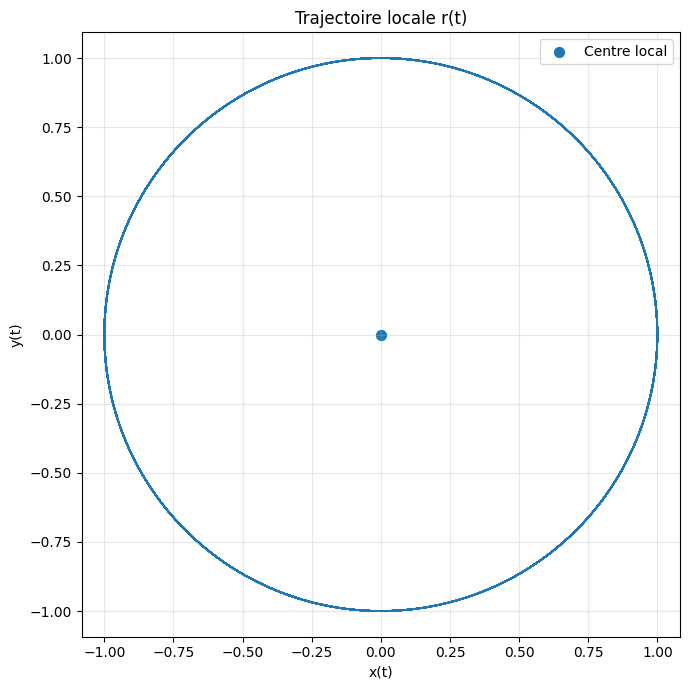

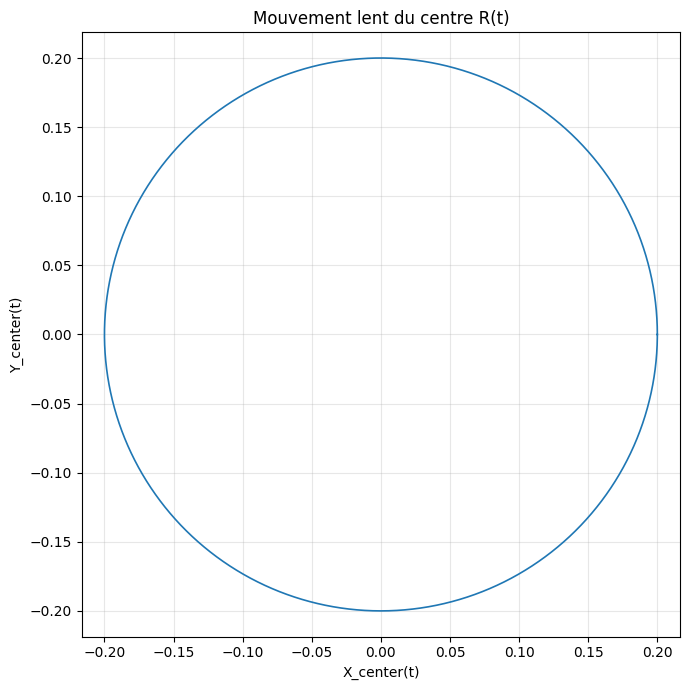

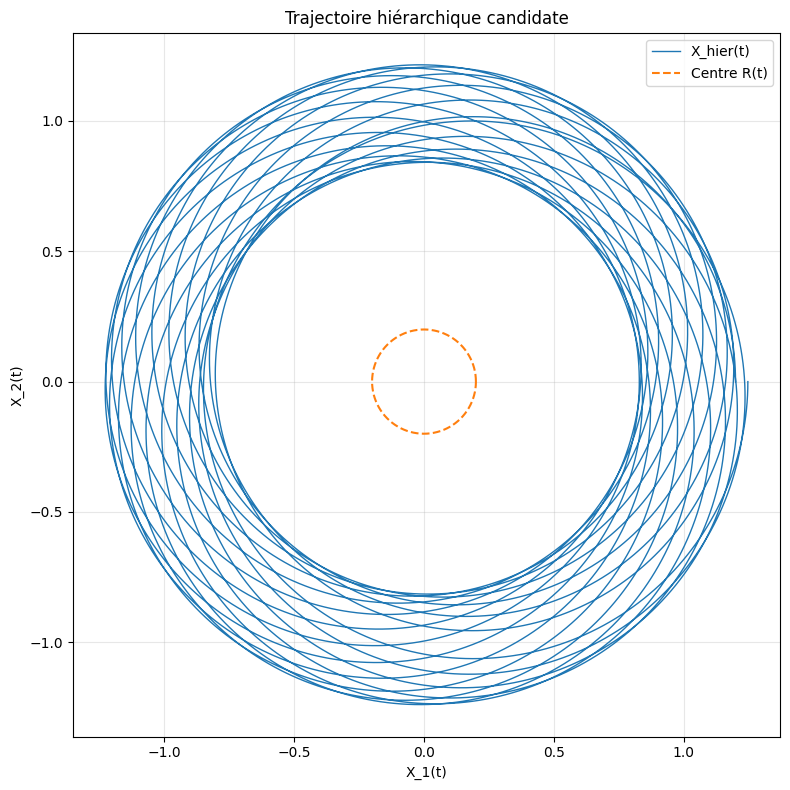

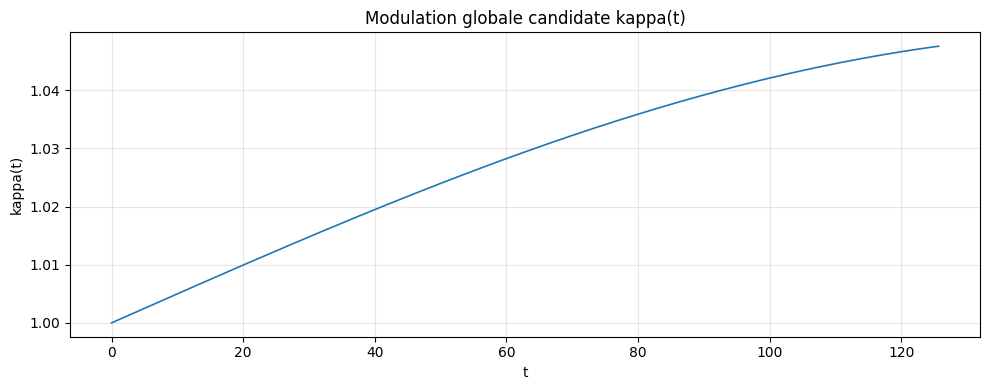

In [3]:
# ============================================================
# 8. Figure 1 — Trajectoire locale
# ============================================================

plt.figure(figsize=(7, 7))

plt.plot(
    r_local[:, 0],
    r_local[:, 1],
    linewidth=1.2
)

plt.scatter(
    [0],
    [0],
    s=50,
    label="Centre local"
)

plt.xlabel("x(t)")
plt.ylabel("y(t)")
plt.title("Trajectoire locale r(t)")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 9. Figure 2 — Mouvement lent du centre
# ============================================================

plt.figure(figsize=(7, 7))

plt.plot(
    R_center[:, 0],
    R_center[:, 1],
    linewidth=1.2
)

plt.xlabel("X_center(t)")
plt.ylabel("Y_center(t)")
plt.title("Mouvement lent du centre R(t)")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 10. Figure 3 — Trajectoire hiérarchique candidate
# ============================================================

plt.figure(figsize=(8, 8))

plt.plot(
    X_hier[:, 0],
    X_hier[:, 1],
    linewidth=1.0,
    label="X_hier(t)"
)

plt.plot(
    R_center[:, 0],
    R_center[:, 1],
    linestyle="--",
    linewidth=1.5,
    label="Centre R(t)"
)

plt.xlabel("X_1(t)")
plt.ylabel("X_2(t)")
plt.title("Trajectoire hiérarchique candidate")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 11. Figure 4 — Modulation globale kappa(t)
# ============================================================

plt.figure(figsize=(10, 4))

plt.plot(
    t,
    kappa,
    linewidth=1.2
)

plt.xlabel("t")
plt.ylabel("kappa(t)")
plt.title("Modulation globale candidate kappa(t)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# 8. Calcul de D_T pour les deux représentations
# ============================================================

# Ancienne forme locale
delta_local = np.diff(r_local, axis=0)
D_T_local = np.linalg.norm(delta_local, axis=1)

# Forme hiérarchique candidate
delta_hier = np.diff(X_hier, axis=0)
D_T_hier = np.linalg.norm(delta_hier, axis=1)


# ============================================================
# 9. Vérifications numériques
# ============================================================

print("Dimensions :")
print("D_T_local :", D_T_local.shape)
print("D_T_hier  :", D_T_hier.shape)

print("\nAncienne forme locale :")
print(f"D_T_mean = {D_T_local.mean():.12f}")
print(f"D_T_std  = {D_T_local.std():.12f}")
print(f"D_T_min  = {D_T_local.min():.12f}")
print(f"D_T_max  = {D_T_local.max():.12f}")

print("\nForme hiérarchique candidate :")
print(f"D_T_mean = {D_T_hier.mean():.12f}")
print(f"D_T_std  = {D_T_hier.std():.12f}")
print(f"D_T_min  = {D_T_hier.min():.12f}")
print(f"D_T_max  = {D_T_hier.max():.12f}")

Dimensions :
D_T_local : (4999,)
D_T_hier  : (4999,)

Ancienne forme locale :
D_T_mean = 0.025137106923
D_T_std  = 0.000000000000
D_T_min  = 0.025137106923
D_T_max  = 0.025137106923

Forme hiérarchique candidate :
D_T_mean = 0.025828824357
D_T_std  = 0.000398804305
D_T_min  = 0.024926951317
D_T_max  = 0.026583758322


In [5]:
# ============================================================
# 10. Calcul de S_T = |Delta D_T|
# ============================================================

S_T_local = np.abs(np.diff(D_T_local))
S_T_hier = np.abs(np.diff(D_T_hier))

print("Dimensions :")
print("S_T_local :", S_T_local.shape)
print("S_T_hier  :", S_T_hier.shape)

print("\nAncienne forme locale :")
print(f"S_T_mean = {S_T_local.mean():.12e}")
print(f"S_T_std  = {S_T_local.std():.12e}")
print(f"S_T_min  = {S_T_local.min():.12e}")
print(f"S_T_max  = {S_T_local.max():.12e}")

print("\nForme hiérarchique candidate :")
print(f"S_T_mean = {S_T_hier.mean():.12e}")
print(f"S_T_std  = {S_T_hier.std():.12e}")
print(f"S_T_min  = {S_T_hier.min():.12e}")
print(f"S_T_max  = {S_T_hier.max():.12e}")

Dimensions :
S_T_local : (4998,)
S_T_hier  : (4998,)

Ancienne forme locale :
S_T_mean = 5.175590876018e-15
S_T_std  = 5.773557163201e-15
S_T_min  = 0.000000000000e+00
S_T_max  = 1.439473540366e-14

Forme hiérarchique candidate :
S_T_mean = 3.822809928073e-06
S_T_std  = 1.856698111351e-06
S_T_min  = 1.236153009815e-09
S_T_max  = 6.318514922523e-06


In [6]:
# ============================================================
# 11. Normalisation u = D_T / D_T_max
# ============================================================

u_local = D_T_local / D_T_local.max()
u_hier = D_T_hier / D_T_hier.max()

print("Ancienne forme locale :")
print(f"u_mean = {u_local.mean():.12f}")
print(f"u_std  = {u_local.std():.12f}")
print(f"u_min  = {u_local.min():.12f}")
print(f"u_max  = {u_local.max():.12f}")

print("\nForme hiérarchique candidate :")
print(f"u_mean = {u_hier.mean():.12f}")
print(f"u_std  = {u_hier.std():.12f}")
print(f"u_min  = {u_hier.min():.12f}")
print(f"u_max  = {u_hier.max():.12f}")


# ============================================================
# 12. R_super pour quelques seuils fixes
# ============================================================

thresholds = [0.90, 0.95, 0.98, 0.99]

print("\nR_super = fraction des u_i > seuil")

for q in thresholds:
    R_local = np.mean(u_local > q)
    R_hier = np.mean(u_hier > q)

    print(f"\nSeuil q = {q:.2f}")
    print(f"R_super local = {R_local:.12f}")
    print(f"R_super hier  = {R_hier:.12f}")

Ancienne forme locale :
u_mean = 1.000000000000
u_std  = 0.000000000000
u_min  = 0.999999999999
u_max  = 1.000000000000

Forme hiérarchique candidate :
u_mean = 0.971601684194
u_std  = 0.015001802978
u_min  = 0.937675967998
u_max  = 1.000000000000

R_super = fraction des u_i > seuil

Seuil q = 0.90
R_super local = 1.000000000000
R_super hier  = 1.000000000000

Seuil q = 0.95
R_super local = 1.000000000000
R_super hier  = 0.907581516303

Seuil q = 0.98
R_super local = 1.000000000000
R_super hier  = 0.330266053211

Seuil q = 0.99
R_super local = 1.000000000000
R_super hier  = 0.120624124825


Courbe locale :
R_min = 1.000000000000
R_max = 1.000000000000
Nombre de valeurs uniques = 1

Courbe hiérarchique :
R_min = 0.003800760152
R_max = 1.000000000000
Nombre de valeurs uniques = 125


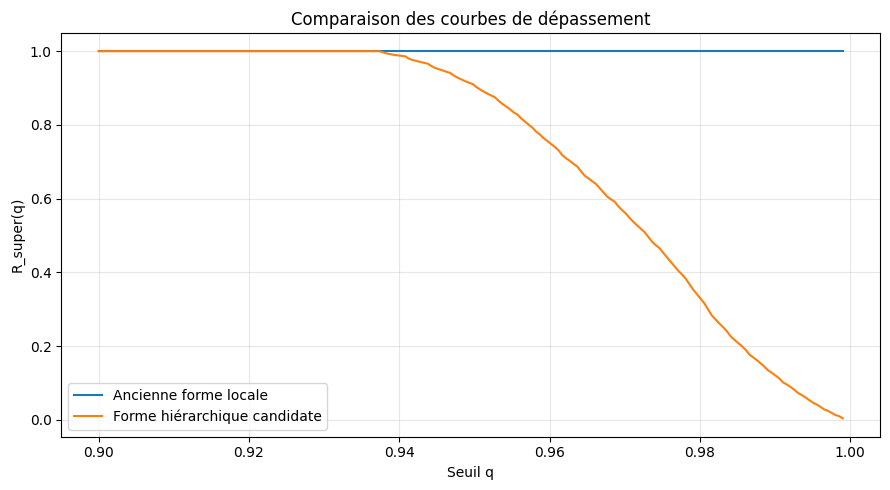

In [7]:
# ============================================================
# 13. Courbe complète R_super(q)
# ============================================================

q_grid = np.linspace(0.90, 0.999, 200)

R_super_local = np.array([
    np.mean(u_local > q)
    for q in q_grid
])

R_super_hier = np.array([
    np.mean(u_hier > q)
    for q in q_grid
])


# ============================================================
# 14. Diagnostics numériques
# ============================================================

print("Courbe locale :")
print(f"R_min = {R_super_local.min():.12f}")
print(f"R_max = {R_super_local.max():.12f}")
print(f"Nombre de valeurs uniques = {len(np.unique(R_super_local))}")

print("\nCourbe hiérarchique :")
print(f"R_min = {R_super_hier.min():.12f}")
print(f"R_max = {R_super_hier.max():.12f}")
print(f"Nombre de valeurs uniques = {len(np.unique(R_super_hier))}")


# ============================================================
# 15. Visualisation
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    q_grid,
    R_super_local,
    label="Ancienne forme locale"
)

plt.plot(
    q_grid,
    R_super_hier,
    label="Forme hiérarchique candidate"
)

plt.xlabel("Seuil q")
plt.ylabel("R_super(q)")
plt.title("Comparaison des courbes de dépassement")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Forme locale :
Non identifiable pour B_H sur ce contrôle, car R_super(q) est constant.

Forme hiérarchique candidate — fit exploratoire OLS-log :
N_fit   = 200
A_H     = 71228341527.944427490234
B_H     = 26.953252882152
R2_log  = 0.591965441793
RMSElog = 6.427284802596e-01
RMSE_R  = 3.633803175181e-01


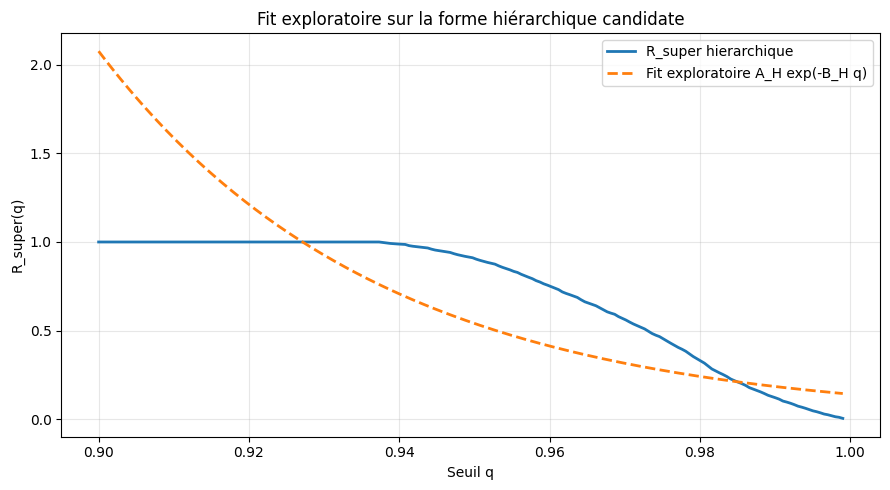

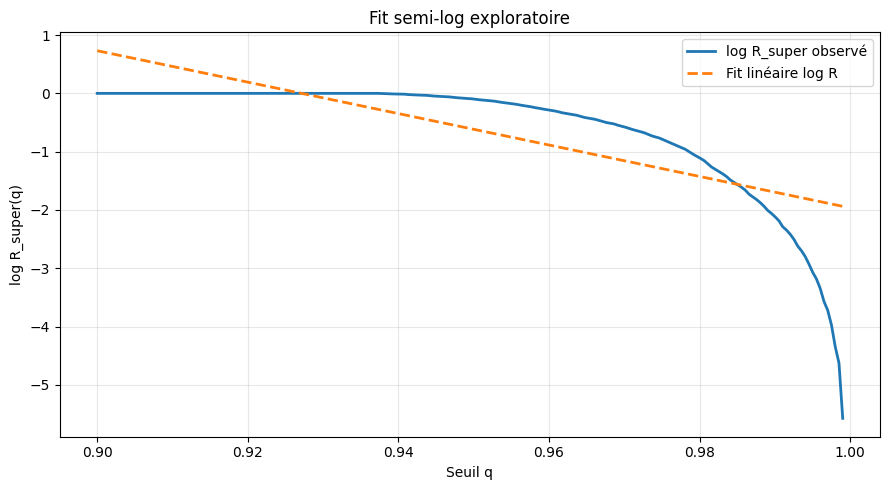

In [8]:
# ============================================================
# 16. Fit exploratoire : R(q) = A_H exp(-B_H q)
#     Forme locale déclarée non identifiable
# ============================================================

# La forme locale est dégénérée : R_super(q)=1 partout sur cette grille.
print("Forme locale :")
print("Non identifiable pour B_H sur ce contrôle, car R_super(q) est constant.")

# Fit uniquement sur la forme hiérarchique
mask_fit = R_super_hier > 0

q_fit = q_grid[mask_fit]
R_fit = R_super_hier[mask_fit]

log_R = np.log(R_fit)

# Modèle : log R = alpha - B_H q
# polyfit donne log_R ≈ slope*q + intercept
slope, intercept = np.polyfit(q_fit, log_R, 1)

A_H = np.exp(intercept)
B_H = -slope

log_R_pred = intercept + slope * q_fit
R_pred = A_H * np.exp(-B_H * q_fit)

# Diagnostics
res_log = log_R - log_R_pred
rmse_log = np.sqrt(np.mean(res_log**2))

res_R = R_fit - R_pred
rmse_R = np.sqrt(np.mean(res_R**2))

ss_res = np.sum(res_log**2)
ss_tot = np.sum((log_R - log_R.mean())**2)
R2_log = 1.0 - ss_res / ss_tot

N_fit = len(q_fit)

print("\nForme hiérarchique candidate — fit exploratoire OLS-log :")
print(f"N_fit   = {N_fit}")
print(f"A_H     = {A_H:.12f}")
print(f"B_H     = {B_H:.12f}")
print(f"R2_log  = {R2_log:.12f}")
print(f"RMSElog = {rmse_log:.12e}")
print(f"RMSE_R  = {rmse_R:.12e}")


# ============================================================
# 17. Visualisation du fit
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(q_grid, R_super_hier, label="R_super hierarchique", linewidth=2)
plt.plot(q_fit, R_pred, "--", label="Fit exploratoire A_H exp(-B_H q)", linewidth=2)

plt.xlabel("Seuil q")
plt.ylabel("R_super(q)")
plt.title("Fit exploratoire sur la forme hiérarchique candidate")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 5))

plt.plot(q_fit, log_R, label="log R_super observé", linewidth=2)
plt.plot(q_fit, log_R_pred, "--", label="Fit linéaire log R", linewidth=2)

plt.xlabel("Seuil q")
plt.ylabel("log R_super(q)")
plt.title("Fit semi-log exploratoire")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# 18. Sensibilité du fit à la fenêtre de seuils
# ============================================================

windows = [
    (0.90, 0.999),
    (0.94, 0.995),
    (0.95, 0.995),
    (0.96, 0.995),
    (0.97, 0.995),
]

results_windows = []

for q_min_w, q_max_w in windows:
    mask = (
        (q_grid >= q_min_w)
        & (q_grid <= q_max_w)
        & (R_super_hier > 0)
        & (R_super_hier < 1.0)
    )

    q_w = q_grid[mask]
    R_w = R_super_hier[mask]

    if len(q_w) < 5:
        results_windows.append((q_min_w, q_max_w, len(q_w), np.nan, np.nan, np.nan, np.nan, np.nan))
        continue

    log_R_w = np.log(R_w)

    slope_w, intercept_w = np.polyfit(q_w, log_R_w, 1)

    A_w = np.exp(intercept_w)
    B_w = -slope_w

    log_pred_w = intercept_w + slope_w * q_w
    R_pred_w = A_w * np.exp(-B_w * q_w)

    rmse_log_w = np.sqrt(np.mean((log_R_w - log_pred_w) ** 2))
    rmse_R_w = np.sqrt(np.mean((R_w - R_pred_w) ** 2))

    ss_res_w = np.sum((log_R_w - log_pred_w) ** 2)
    ss_tot_w = np.sum((log_R_w - log_R_w.mean()) ** 2)
    R2_w = 1.0 - ss_res_w / ss_tot_w

    results_windows.append((q_min_w, q_max_w, len(q_w), A_w, B_w, R2_w, rmse_log_w, rmse_R_w))


print("Sensibilité du fit exponentiel selon la fenêtre :")
print("q_min | q_max | N_fit | A_H | B_H | R2_log | RMSE_log | RMSE_R")

for row in results_windows:
    print(
        f"{row[0]:.3f} | {row[1]:.3f} | {row[2]:5d} | "
        f"{row[3]:.6e} | {row[4]:.6f} | {row[5]:.6f} | "
        f"{row[6]:.6e} | {row[7]:.6e}"
    )

Sensibilité du fit exponentiel selon la fenêtre :
q_min | q_max | N_fit | A_H | B_H | R2_log | RMSE_log | RMSE_R
0.900 | 0.999 |   124 | 5.747956e+22 | 55.119763 | 0.756491 | 5.568810e-01 | 2.956102e-01
0.940 | 0.995 |   110 | 3.333120e+18 | 44.887415 | 0.852912 | 2.944605e-01 | 1.724735e-01
0.950 | 0.995 |    90 | 1.073313e+23 | 55.497845 | 0.890315 | 2.517585e-01 | 1.317547e-01
0.960 | 0.995 |    70 | 1.397476e+29 | 69.841119 | 0.923432 | 2.021517e-01 | 9.076709e-02
0.970 | 0.995 |    50 | 1.660382e+38 | 91.056521 | 0.959908 | 1.335978e-01 | 4.563518e-02


Diagnostic B_eff(q) :
N_eff_points = 124
B_eff_min    = 2.647283
B_eff_mean   = 97.994830
B_eff_median = 35.375910
B_eff_max    = 1904.332146
B_eff_std    = 220.430377


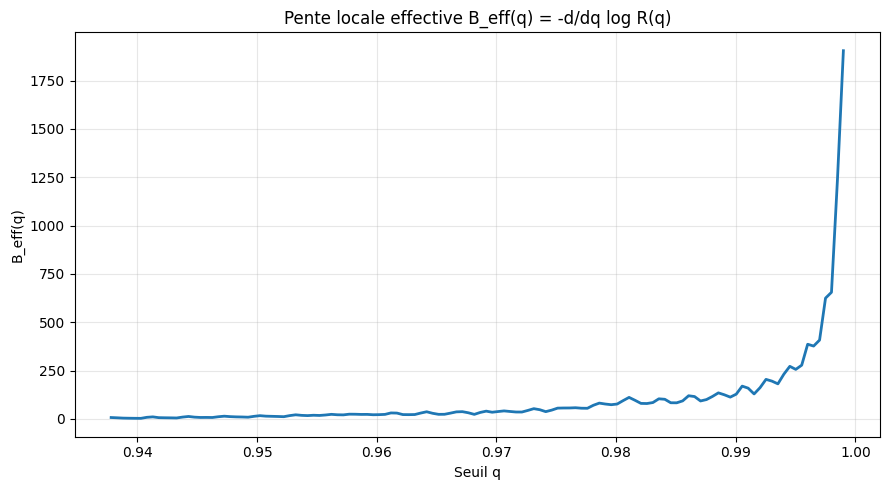

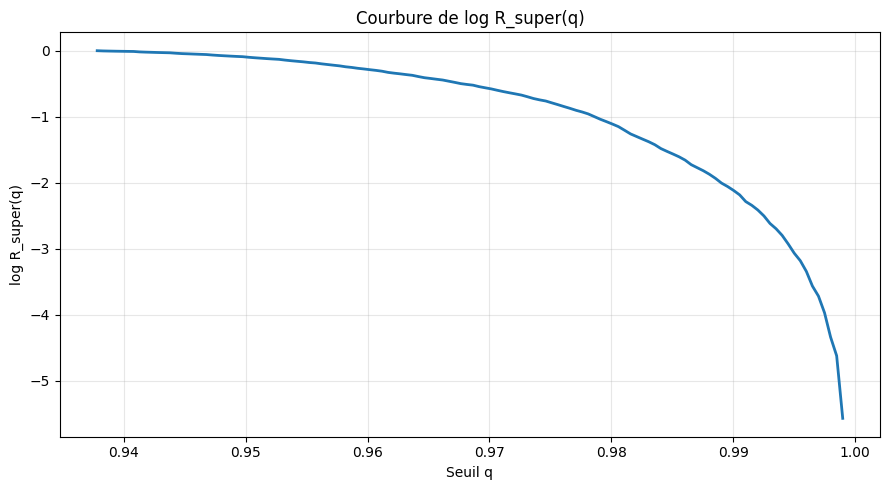

In [10]:
# ============================================================
# 19. Pente locale effective B_eff(q)
#
# B_eff(q) = - d/dq log R(q)
# ============================================================

# On garde seulement les points valides
mask_eff = (
    (R_super_hier > 0)
    & (R_super_hier < 1.0)
)

q_eff = q_grid[mask_eff]
log_R_eff = np.log(R_super_hier[mask_eff])

# Dérivée numérique
dlogR_dq = np.gradient(log_R_eff, q_eff)

B_eff = -dlogR_dq

print("Diagnostic B_eff(q) :")
print(f"N_eff_points = {len(B_eff)}")
print(f"B_eff_min    = {np.nanmin(B_eff):.6f}")
print(f"B_eff_mean   = {np.nanmean(B_eff):.6f}")
print(f"B_eff_median = {np.nanmedian(B_eff):.6f}")
print(f"B_eff_max    = {np.nanmax(B_eff):.6f}")
print(f"B_eff_std    = {np.nanstd(B_eff):.6f}")


# ============================================================
# 20. Visualisation de B_eff(q)
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(q_eff, B_eff, linewidth=2)

plt.xlabel("Seuil q")
plt.ylabel("B_eff(q)")
plt.title("Pente locale effective B_eff(q) = -d/dq log R(q)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 21. Comparaison log R et pente locale
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(q_eff, log_R_eff, linewidth=2)

plt.xlabel("Seuil q")
plt.ylabel("log R_super(q)")
plt.title("Courbure de log R_super(q)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# 22. Quantiles robustes de B_eff(q)
# ============================================================

quantile_levels = [50, 75, 90, 95, 99]

B_eff_quantiles = np.percentile(B_eff, quantile_levels)

print("Quantiles de B_eff(q) :")
for level, value in zip(quantile_levels, B_eff_quantiles):
    print(f"Q{level:02d} = {value:.6f}")

print("\nRatios de divergence :")
print(f"Q95 / Q50 = {B_eff_quantiles[3] / B_eff_quantiles[0]:.6f}")
print(f"Q99 / Q50 = {B_eff_quantiles[4] / B_eff_quantiles[0]:.6f}")
print(f"Max / Q50 = {B_eff.max() / B_eff_quantiles[0]:.6f}")

Quantiles de B_eff(q) :
Q50 = 35.375910
Q75 = 93.257239
Q90 = 190.906389
Q95 = 361.745254
Q99 = 1102.439211

Ratios de divergence :
Q95 / Q50 = 10.225751
Q99 / Q50 = 31.163557
Max / Q50 = 53.831325


In [12]:
# ============================================================
# 23. Ablation contrôlée — définition des 4 formes
# ============================================================

# 1. Local seul
X_local_only = r_local.copy()

# 2. Centre ajouté, sans modulation globale
# X(t) = R(t) + r(t)
X_center_only = R_center + r_local

# 3. Modulation seule, centre fixé à zéro
# X(t) = kappa(t) r(t)
X_kappa_only = kappa[:, None] * r_local

# 4. Forme complète
# X(t) = R(t) + kappa(t) r(t)
X_full = R_center + kappa[:, None] * r_local


ablation_cases = {
    "local_only": X_local_only,
    "center_only": X_center_only,
    "kappa_only": X_kappa_only,
    "full": X_full,
}


print("Cas d'ablation définis :")
for name, X in ablation_cases.items():
    print(f"{name:12s} : {X.shape}")

Cas d'ablation définis :
local_only   : (5000, 2)
center_only  : (5000, 2)
kappa_only   : (5000, 2)
full         : (5000, 2)


In [13]:
# ============================================================
# 24. Ablation contrôlée — calcul de D_T, S_T et u
# ============================================================

ablation_obs = {}

for name, X in ablation_cases.items():

    # --------------------------------------------------------
    # D_T = norme du déplacement discret
    # --------------------------------------------------------
    delta_X = np.diff(X, axis=0)

    D_T = np.linalg.norm(
        delta_X,
        axis=1
    )

    # --------------------------------------------------------
    # S_T = |Delta D_T|
    # --------------------------------------------------------
    S_T = np.abs(
        np.diff(D_T)
    )

    # --------------------------------------------------------
    # u = D_T / D_T_max
    # --------------------------------------------------------
    D_T_max = np.max(D_T)

    if D_T_max > 0:
        u = D_T / D_T_max
    else:
        u = np.full_like(D_T, np.nan)

    # --------------------------------------------------------
    # Stockage
    # --------------------------------------------------------
    ablation_obs[name] = {
        "D_T": D_T,
        "S_T": S_T,
        "u": u
    }


# ============================================================
# 25. Résumé numérique
# ============================================================

print(
    "Cas          | D_T_mean     | D_T_std      | "
    "S_T_mean     | S_T_max      | u_mean       | u_std"
)

print("-" * 105)

for name, obs in ablation_obs.items():

    D_T = obs["D_T"]
    S_T = obs["S_T"]
    u = obs["u"]

    print(
        f"{name:12s} | "
        f"{D_T.mean():.10f} | "
        f"{D_T.std():.10f} | "
        f"{S_T.mean():.6e} | "
        f"{S_T.max():.6e} | "
        f"{u.mean():.10f} | "
        f"{u.std():.10f}"
    )

Cas          | D_T_mean     | D_T_std      | S_T_mean     | S_T_max      | u_mean       | u_std
---------------------------------------------------------------------------------------------------------
local_only   | 0.0251371069 | 0.0000000000 | 5.175591e-15 | 1.439474e-14 | 1.0000000000 | 0.0000000000
center_only  | 0.0251377354 | 0.0001777492 | 3.822379e-06 | 6.002977e-06 | 0.9901235083 | 0.0070011737
kappa_only   | 0.0258282119 | 0.0003570662 | 2.391218e-07 | 3.159453e-07 | 0.9808529791 | 0.0135599577
full         | 0.0258288244 | 0.0003988043 | 3.822810e-06 | 6.318515e-06 | 0.9716016842 | 0.0150018030


Cas          | R_min        | R_max        | N_unique | R(0.95)     | R(0.98)     | R(0.99)
----------------------------------------------------------------------------------------------------
local_only   | 1.0000000000 | 1.0000000000 |        1 | 1.0000000000 | 1.0000000000 | 1.0000000000
center_only  | 0.1448289658 | 1.0000000000 |       39 | 1.0000000000 | 1.0000000000 | 0.5049009802
kappa_only   | 0.0494098820 | 1.0000000000 |       91 | 1.0000000000 | 0.5535107021 | 0.3352670534
full         | 0.0038007602 | 1.0000000000 |      125 | 0.9075815163 | 0.3302660532 | 0.1206241248


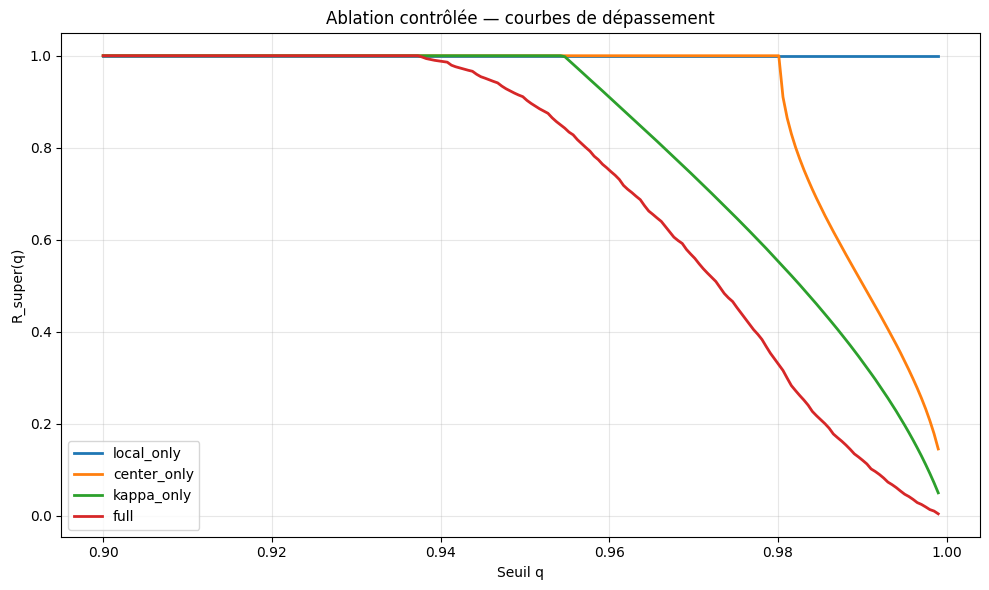

In [14]:
# ============================================================
# 26. Ablation contrôlée — R_super(q) sur grille commune
# ============================================================

q_grid_ablation = np.linspace(0.90, 0.999, 200)

R_ablation = {}

for name, obs in ablation_obs.items():

    u = obs["u"]

    R_q = np.array([
        np.mean(u > q)
        for q in q_grid_ablation
    ])

    R_ablation[name] = R_q


# ============================================================
# 27. Résumé numérique
# ============================================================

print(
    "Cas          | R_min        | R_max        | "
    "N_unique | R(0.95)     | R(0.98)     | R(0.99)"
)

print("-" * 100)

for name, R_q in R_ablation.items():

    R_095 = np.mean(
        ablation_obs[name]["u"] > 0.95
    )

    R_098 = np.mean(
        ablation_obs[name]["u"] > 0.98
    )

    R_099 = np.mean(
        ablation_obs[name]["u"] > 0.99
    )

    print(
        f"{name:12s} | "
        f"{R_q.min():.10f} | "
        f"{R_q.max():.10f} | "
        f"{len(np.unique(R_q)):8d} | "
        f"{R_095:.10f} | "
        f"{R_098:.10f} | "
        f"{R_099:.10f}"
    )


# ============================================================
# 28. Visualisation comparative
# ============================================================

plt.figure(figsize=(10, 6))

for name, R_q in R_ablation.items():
    plt.plot(
        q_grid_ablation,
        R_q,
        linewidth=2,
        label=name
    )

plt.xlabel("Seuil q")
plt.ylabel("R_super(q)")
plt.title("Ablation contrôlée — courbes de dépassement")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Cas          | N_pts | B_min    | B_median | B_mean   | B_max
---------------------------------------------------------------------------
center_only  |    38 |   55.094 |   70.124 |  104.050 |  414.945
kappa_only   |    90 |   16.587 |   30.623 |   71.303 |  734.777
full         |   124 |    2.647 |   35.376 |   97.995 | 1904.332

Quantiles de B_eff(q) par cas :
Cas          | Q50      | Q75      | Q90      | Q95      | Q99
--------------------------------------------------------------------------------
center_only  |   70.124 |  103.106 |  188.206 |  279.786 |  393.229
kappa_only   |   30.623 |   60.484 |  146.194 |  263.051 |  633.159
full         |   35.376 |   93.257 |  190.906 |  361.745 | 1102.439


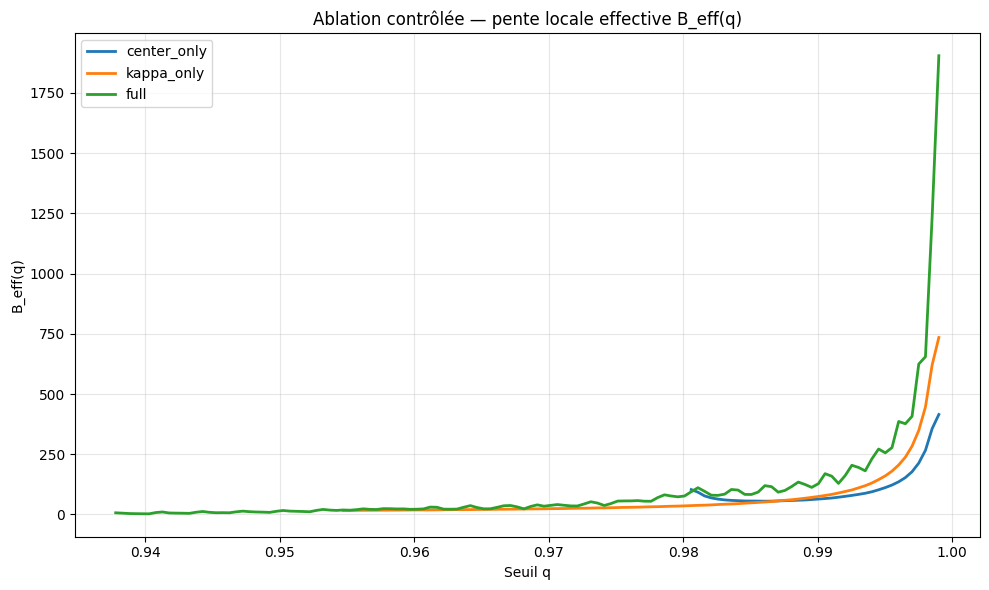

In [15]:
# ============================================================
# 29. B_eff(q) par ablation : center_only, kappa_only, full
# ============================================================

cases_for_Beff = ["center_only", "kappa_only", "full"]
quantile_levels = [50, 75, 90, 95, 99]

B_eff_ablation = {}

print("Cas          | N_pts | B_min    | B_median | B_mean   | B_max")
print("-" * 75)

for name in cases_for_Beff:
    R_q = R_ablation[name]

    mask = (R_q > 0) & (R_q < 1.0)

    q_valid = q_grid_ablation[mask]
    log_R_valid = np.log(R_q[mask])

    dlogR_dq = np.gradient(log_R_valid, q_valid)
    B_eff_case = -dlogR_dq

    B_eff_ablation[name] = {
        "q": q_valid,
        "B_eff": B_eff_case
    }

    print(
        f"{name:12s} | "
        f"{len(B_eff_case):5d} | "
        f"{np.min(B_eff_case):8.3f} | "
        f"{np.median(B_eff_case):8.3f} | "
        f"{np.mean(B_eff_case):8.3f} | "
        f"{np.max(B_eff_case):8.3f}"
    )


# ============================================================
# 30. Quantiles de B_eff(q)
# ============================================================

print("\nQuantiles de B_eff(q) par cas :")
print("Cas          | Q50      | Q75      | Q90      | Q95      | Q99")
print("-" * 80)

for name in cases_for_Beff:
    B = B_eff_ablation[name]["B_eff"]
    Q = np.percentile(B, quantile_levels)

    print(
        f"{name:12s} | "
        f"{Q[0]:8.3f} | "
        f"{Q[1]:8.3f} | "
        f"{Q[2]:8.3f} | "
        f"{Q[3]:8.3f} | "
        f"{Q[4]:8.3f}"
    )


# ============================================================
# 31. Visualisation comparative de B_eff(q)
# ============================================================

plt.figure(figsize=(10, 6))

for name in cases_for_Beff:
    q_valid = B_eff_ablation[name]["q"]
    B = B_eff_ablation[name]["B_eff"]

    plt.plot(
        q_valid,
        B,
        linewidth=2,
        label=name
    )

plt.xlabel("Seuil q")
plt.ylabel("B_eff(q)")
plt.title("Ablation contrôlée — pente locale effective B_eff(q)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Fenêtre commune : q ∈ [0.982, 0.998]

Cas          | N_pts | Q50      | Q75      | Q90      | Q95      | Q99
-------------------------------------------------------------------------------------
center_only  |    32 |   64.622 |   89.554 |  134.304 |  164.072 |  187.202
kappa_only   |    32 |   72.763 |  122.182 |  202.970 |  258.465 |  302.816
full         |    32 |  128.265 |  210.899 |  366.692 |  395.625 |  476.533


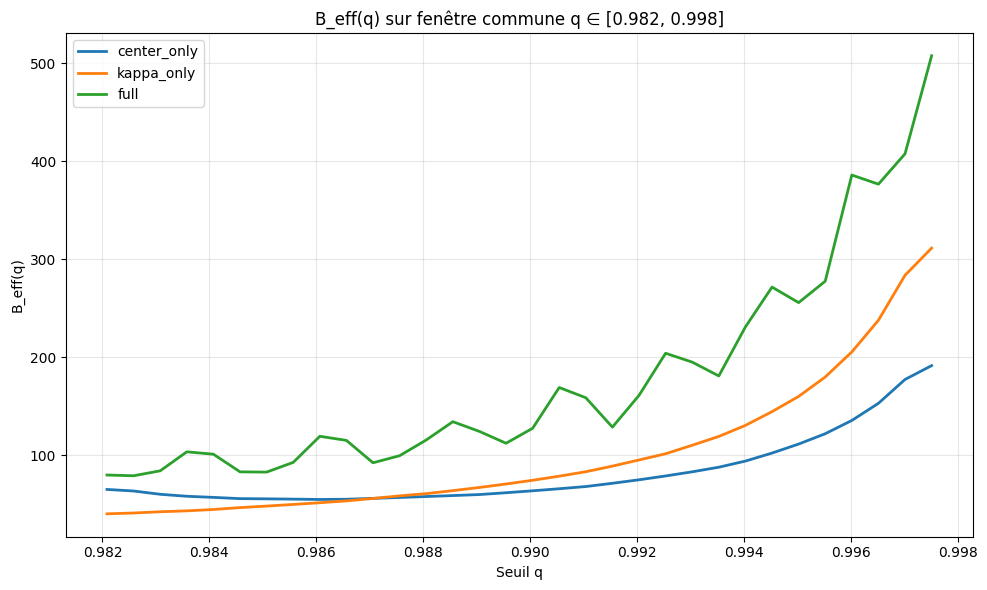

In [16]:
# ============================================================
# 32. B_eff(q) sur une fenêtre commune stricte
# ============================================================

q_common_min = 0.982
q_common_max = 0.998

print(f"Fenêtre commune : q ∈ [{q_common_min}, {q_common_max}]")

print("\nCas          | N_pts | Q50      | Q75      | Q90      | Q95      | Q99")
print("-" * 85)

B_eff_common = {}

for name in ["center_only", "kappa_only", "full"]:

    R_q = R_ablation[name]

    mask_common = (
        (q_grid_ablation >= q_common_min)
        & (q_grid_ablation <= q_common_max)
        & (R_q > 0)
        & (R_q < 1.0)
    )

    q_c = q_grid_ablation[mask_common]
    R_c = R_q[mask_common]

    if len(q_c) < 5:
        print(f"{name:12s} | {len(q_c):5d} | non fiable : trop peu de points")
        continue

    log_R_c = np.log(R_c)

    dlogR_dq_c = np.gradient(log_R_c, q_c)
    B_eff_c = -dlogR_dq_c

    Q = np.percentile(B_eff_c, [50, 75, 90, 95, 99])

    B_eff_common[name] = {
        "q": q_c,
        "B_eff": B_eff_c,
        "Q": Q
    }

    print(
        f"{name:12s} | "
        f"{len(B_eff_c):5d} | "
        f"{Q[0]:8.3f} | "
        f"{Q[1]:8.3f} | "
        f"{Q[2]:8.3f} | "
        f"{Q[3]:8.3f} | "
        f"{Q[4]:8.3f}"
    )


# ============================================================
# 33. Visualisation sur fenêtre commune
# ============================================================

plt.figure(figsize=(10, 6))

for name, data in B_eff_common.items():
    plt.plot(
        data["q"],
        data["B_eff"],
        linewidth=2,
        label=name
    )

plt.xlabel("Seuil q")
plt.ylabel("B_eff(q)")
plt.title("B_eff(q) sur fenêtre commune q ∈ [0.982, 0.998]")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 13.1 — Validation pré-déphasage de l’endpoint GVH

Les quatre cas sont désormais figés :

\[
X_0(t)=r(t)
\]

\[
X_C(t)=R(t)+r(t)
\]

\[
X_K(t)=\kappa(t)r(t)
\]

\[
X_F(t)=R(t)+\kappa(t)r(t)
\]

Paramètres figés :

\[
N=5000,\quad a=0.2,\quad \omega=0.05,\quad \epsilon=0.05,\quad \Omega=0.01
\]

Aucun paramètre ne sera modifié après inspection du nouvel endpoint.

In [17]:
# ============================================================
# 13.1 — Étape 1 : vérification du gel des cas
# ============================================================

frozen_parameters = {
    "N": N,
    "a": a,
    "omega": omega,
    "epsilon": epsilon,
    "Omega": Omega,
}

frozen_cases = {
    "X_0_local": X_local_only,
    "X_C_center": X_center_only,
    "X_K_kappa": X_kappa_only,
    "X_F_full": X_full,
}

print("Paramètres figés :")
for key, value in frozen_parameters.items():
    print(f"{key:8s} = {value}")

print("\nCas figés :")
for name, X in frozen_cases.items():
    print(f"{name:12s} : {X.shape}")

print("\nStatut : cas et paramètres gelés pour 13.1")

Paramètres figés :
N        = 5000
a        = 0.2
omega    = 0.05
epsilon  = 0.05
Omega    = 0.01

Cas figés :
X_0_local    : (5000, 2)
X_C_center   : (5000, 2)
X_K_kappa    : (5000, 2)
X_F_full     : (5000, 2)

Statut : cas et paramètres gelés pour 13.1


In [18]:
# ============================================================
# 13.1 — Étape 2 : contrôles synthétiques à vérité connue
# ============================================================

rng = np.random.default_rng(12345)

N_D = 4999

# Loi F : exponentielle de moyenne comparable à D_T local
mean_ref = D_T_local.mean()

D_A = rng.exponential(scale=mean_ref, size=N_D)
D_B = rng.exponential(scale=mean_ref, size=N_D)

# Loi G : Gamma avec même moyenne mais forme différente
# shape > 1 réduit la masse près de zéro et modifie la queue
gamma_shape = 2.0
gamma_scale = mean_ref / gamma_shape

D_C = rng.gamma(shape=gamma_shape, scale=gamma_scale, size=N_D)

synthetic_D_cases = {
    "D_A_F": D_A,
    "D_B_F": D_B,
    "D_C_Gamma": D_C,
}

print("Contrôles synthétiques définis :")
for name, D in synthetic_D_cases.items():
    print(
        f"{name:10s} | "
        f"N={len(D):5d} | "
        f"mean={D.mean():.10f} | "
        f"std={D.std():.10f} | "
        f"min={D.min():.10f} | "
        f"max={D.max():.10f}"
    )

print("\nContrôle nul : D_A_F vs D_B_F")
print("Contrôle positif : D_A_F vs D_C_Gamma")

Contrôles synthétiques définis :
D_A_F      | N= 4999 | mean=0.0249639373 | std=0.0249082669 | min=0.0000012948 | max=0.2310207947
D_B_F      | N= 4999 | mean=0.0251647391 | std=0.0252188293 | min=0.0000001864 | max=0.1822354490
D_C_Gamma  | N= 4999 | mean=0.0252232252 | std=0.0175523631 | min=0.0002558205 | max=0.1290700952

Contrôle nul : D_A_F vs D_B_F
Contrôle positif : D_A_F vs D_C_Gamma


Grille absolue commune :
M_d   = 300
d_min = 0.000000000000
d_max = 0.115760655366

Survie aux bornes :
A : R(d_min)=1.000000 | R(d_max)=0.009402
B : R(d_min)=1.000000 | R(d_max)=0.010802
C : R(d_min)=1.000000 | R(d_max)=0.001000


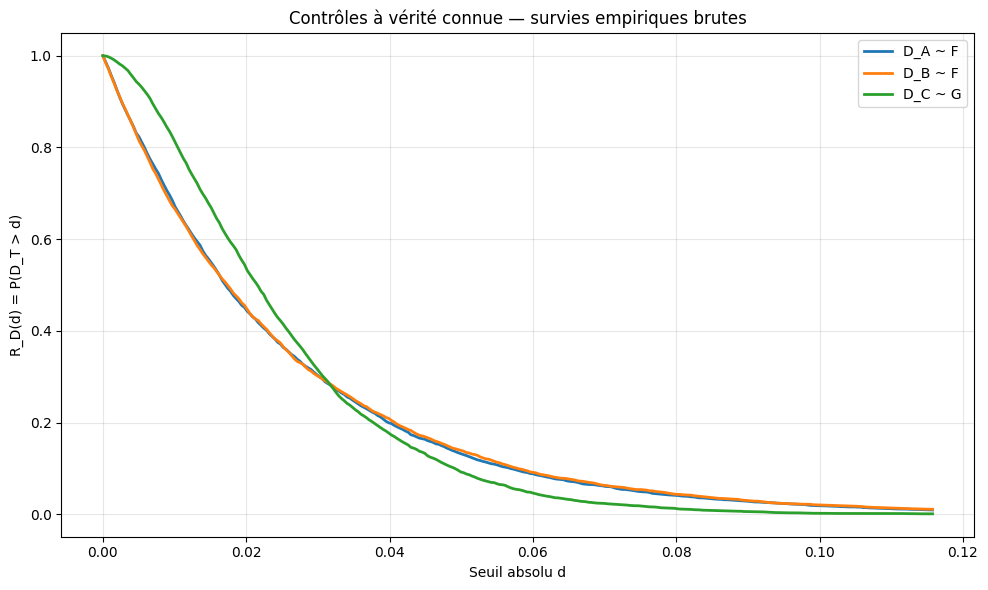

In [19]:
# ============================================================
# 13.1 — Étape 2B
# Endpoint brut R_D(d) sur grille absolue commune
# ============================================================

# Grille fixée depuis la loi F théorique de référence,
# et non depuis les maxima observés de D_A, D_B ou D_C.
M_d = 300

d_min = 0.0
d_max = -mean_ref * np.log(0.01)   # quantile théorique 99% de Exp(mean_ref)

d_grid = np.linspace(d_min, d_max, M_d)


def empirical_survival(D, thresholds):
    """
    R_D(d) = fraction des observations D_i > d
    """
    D = np.asarray(D)
    return np.array([
        np.mean(D > d)
        for d in thresholds
    ])


R_D_A = empirical_survival(D_A, d_grid)
R_D_B = empirical_survival(D_B, d_grid)
R_D_C = empirical_survival(D_C, d_grid)


print("Grille absolue commune :")
print(f"M_d   = {M_d}")
print(f"d_min = {d_min:.12f}")
print(f"d_max = {d_max:.12f}")

print("\nSurvie aux bornes :")
print(f"A : R(d_min)={R_D_A[0]:.6f} | R(d_max)={R_D_A[-1]:.6f}")
print(f"B : R(d_min)={R_D_B[0]:.6f} | R(d_max)={R_D_B[-1]:.6f}")
print(f"C : R(d_min)={R_D_C[0]:.6f} | R(d_max)={R_D_C[-1]:.6f}")


# ============================================================
# Visualisation
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(d_grid, R_D_A, linewidth=2, label="D_A ~ F")
plt.plot(d_grid, R_D_B, linewidth=2, label="D_B ~ F")
plt.plot(d_grid, R_D_C, linewidth=2, label="D_C ~ G")

plt.xlabel("Seuil absolu d")
plt.ylabel("R_D(d) = P(D_T > d)")
plt.title("Contrôles à vérité connue — survies empiriques brutes")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# 13.1 — Étape 2C : A_tail sur contrôles à vérité connue
# ============================================================

def tail_area(R, d_grid):
    """
    A_tail = integral R_D(d) dd
    Approximation trapézoïdale sur la grille commune.
    """
    return np.trapz(R, d_grid)


A_tail_A = tail_area(R_D_A, d_grid)
A_tail_B = tail_area(R_D_B, d_grid)
A_tail_C = tail_area(R_D_C, d_grid)

delta_AB = abs(A_tail_A - A_tail_B)
delta_AC = abs(A_tail_A - A_tail_C)

print("A_tail sur grille absolue commune :")
print(f"A_tail(A) = {A_tail_A:.12f}")
print(f"A_tail(B) = {A_tail_B:.12f}")
print(f"A_tail(C) = {A_tail_C:.12f}")

print("\nDifférences :")
print(f"|A - B| contrôle nul      = {delta_AB:.12e}")
print(f"|A - C| contrôle positif  = {delta_AC:.12e}")

print("\nRatio séparation positive / nul :")
print(f"|A-C| / |A-B| = {delta_AC / delta_AB:.6f}")

A_tail sur grille absolue commune :
A_tail(A) = 0.024724529455
A_tail(B) = 0.024948391066
A_tail(C) = 0.025212525308

Différences :
|A - B| contrôle nul      = 2.238616113422e-04
|A - C| contrôle positif  = 4.879958529898e-04

Ratio séparation positive / nul :
|A-C| / |A-B| = 2.179900


/tmp/ipykernel_1485/3929071578.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(R, d_grid)


In [21]:
# ============================================================
# 13.1 — Étape 2D
# Aire de queue préspécifiée sur [Q90(F), Q99(F)]
# ============================================================

d_L = -mean_ref * np.log(0.10)   # Q90 théorique de F
d_U = -mean_ref * np.log(0.01)   # Q99 théorique de F

mask_tail = (d_grid >= d_L) & (d_grid <= d_U)

def tail_area_window(R, d_grid, mask):
    return np.trapezoid(R[mask], d_grid[mask])

A90_99_A = tail_area_window(R_D_A, d_grid, mask_tail)
A90_99_B = tail_area_window(R_D_B, d_grid, mask_tail)
A90_99_C = tail_area_window(R_D_C, d_grid, mask_tail)

delta90_AB = abs(A90_99_A - A90_99_B)
delta90_AC = abs(A90_99_A - A90_99_C)

print("Fenêtre de queue préspécifiée :")
print(f"d_L = Q90(F) = {d_L:.12f}")
print(f"d_U = Q99(F) = {d_U:.12f}")
print(f"N_grid_tail  = {mask_tail.sum()}")

print("\nA_tail[Q90,Q99] :")
print(f"A = {A90_99_A:.12e}")
print(f"B = {A90_99_B:.12e}")
print(f"C = {A90_99_C:.12e}")

print("\nDifférences :")
print(f"|A-B| contrôle nul     = {delta90_AB:.12e}")
print(f"|A-C| contrôle positif = {delta90_AC:.12e}")

print("\nRatio séparation positive / nul :")
print(f"|A-C| / |A-B| = {delta90_AC / delta90_AB:.6f}")

Fenêtre de queue préspécifiée :
d_L = Q90(F) = 0.057880327683
d_U = Q99(F) = 0.115760655366
N_grid_tail  = 150

A_tail[Q90,Q99] :
A = 2.199466469923e-03
B = 2.339568754966e-03
C = 7.500390157562e-04

Différences :
|A-B| contrôle nul     = 1.401022850434e-04
|A-C| contrôle positif = 1.449427454167e-03

Ratio séparation positive / nul :
|A-C| / |A-B| = 10.345495


Endpoint brut A_tail[Q90(F),Q99(F)] sur les quatre cas gelés :
Cas          | D_mean       | D_std        | A_tail_90_99
----------------------------------------------------------------------
X_0_local    | 0.025137106923 | 0.000000000000 | 0.000000000000e+00
X_C_center   | 0.025137735388 | 0.000177749189 | 0.000000000000e+00
X_K_kappa    | 0.025828211852 | 0.000357066216 | 0.000000000000e+00
X_F_full     | 0.025828824357 | 0.000398804305 | 0.000000000000e+00

Différences principales :
Full - Center = 0.000000000000e+00
Full - Kappa  = 0.000000000000e+00
Full - Local  = 0.000000000000e+00


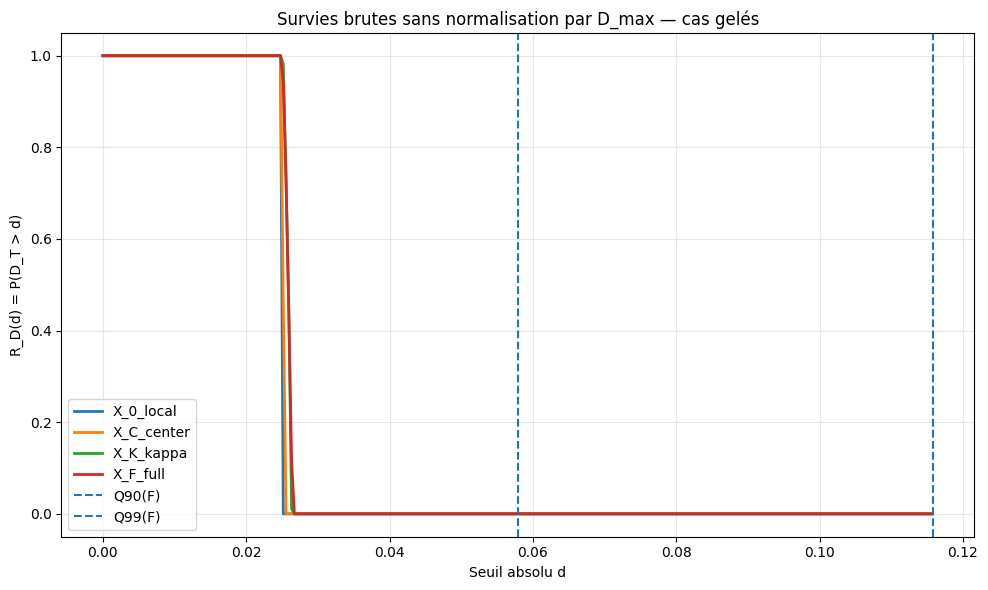

In [22]:
# ============================================================
# 13.1 — Étape 3
# Application de l'endpoint brut aux quatre cas gelés
# Sans normalisation par D_max
# ============================================================

# On récupère les D_T déjà calculés dans ablation_obs
D_frozen = {
    "X_0_local": ablation_obs["local_only"]["D_T"],
    "X_C_center": ablation_obs["center_only"]["D_T"],
    "X_K_kappa": ablation_obs["kappa_only"]["D_T"],
    "X_F_full": ablation_obs["full"]["D_T"],
}

# On utilise exactement la même fenêtre de queue préspécifiée
# que celle validée sur les contrôles à vérité connue :
# [Q90(F), Q99(F)] = [d_L, d_U]
# et la même grille absolue d_grid.

R_D_frozen = {}
A90_99_frozen = {}

for name, D in D_frozen.items():

    R_D = empirical_survival(D, d_grid)
    R_D_frozen[name] = R_D

    A90_99 = tail_area_window(R_D, d_grid, mask_tail)
    A90_99_frozen[name] = A90_99


print("Endpoint brut A_tail[Q90(F),Q99(F)] sur les quatre cas gelés :")
print("Cas          | D_mean       | D_std        | A_tail_90_99")
print("-" * 70)

for name, D in D_frozen.items():
    print(
        f"{name:12s} | "
        f"{D.mean():.12f} | "
        f"{D.std():.12f} | "
        f"{A90_99_frozen[name]:.12e}"
    )


print("\nDifférences principales :")
print(
    "Full - Center = "
    f"{A90_99_frozen['X_F_full'] - A90_99_frozen['X_C_center']:.12e}"
)
print(
    "Full - Kappa  = "
    f"{A90_99_frozen['X_F_full'] - A90_99_frozen['X_K_kappa']:.12e}"
)
print(
    "Full - Local  = "
    f"{A90_99_frozen['X_F_full'] - A90_99_frozen['X_0_local']:.12e}"
)


# ============================================================
# Visualisation des survies brutes
# ============================================================

plt.figure(figsize=(10, 6))

for name, R_D in R_D_frozen.items():
    plt.plot(
        d_grid,
        R_D,
        linewidth=2,
        label=name
    )

plt.axvline(d_L, linestyle="--", linewidth=1.5, label="Q90(F)")
plt.axvline(d_U, linestyle="--", linewidth=1.5, label="Q99(F)")

plt.xlabel("Seuil absolu d")
plt.ylabel("R_D(d) = P(D_T > d)")
plt.title("Survies brutes sans normalisation par D_max — cas gelés")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# 13.1 — Recalibration préspécifiée de la fenêtre GVH
# Référence indépendante de full : X_C_center
# ============================================================

D_ref_GVH = D_frozen["X_C_center"]

d_L_GVH = np.quantile(D_ref_GVH, 0.90)
d_U_GVH = np.quantile(D_ref_GVH, 0.99)

# Grille absolue commune aux quatre cas
N_grid_GVH = 300
d_grid_GVH = np.linspace(d_L_GVH, d_U_GVH, N_grid_GVH)

print("Fenêtre GVH absolue commune :")
print(f"d_L_GVH = Q90(center_only) = {d_L_GVH:.12f}")
print(f"d_U_GVH = Q99(center_only) = {d_U_GVH:.12f}")
print(f"N_grid_GVH = {N_grid_GVH}")

print("\nContrôle des plages D_T :")
for name, D in D_frozen.items():
    print(
        f"{name:12s} | "
        f"min={D.min():.12f} | "
        f"max={D.max():.12f}"
    )

Fenêtre GVH absolue commune :
d_L_GVH = Q90(center_only) = 0.025376266287
d_U_GVH = Q99(center_only) = 0.025388356967
N_grid_GVH = 300

Contrôle des plages D_T :
X_0_local    | min=0.025137106923 | max=0.025137106923
X_C_center   | min=0.024885729252 | max=0.025388484546
X_K_kappa    | min=0.025137268038 | max=0.026332398842
X_F_full     | min=0.024926951317 | max=0.026583758322


Endpoint GVH brut sur fenêtre commune définie par center_only :
Cas          | R(d_L)      | R(d_U)      | A_tail_GVH
----------------------------------------------------------------------
X_0_local    | 0.000000000000 | 0.000000000000 | 0.000000000000e+00
X_C_center   | 0.100020004001 | 0.010002000400 | 8.134408753598e-07
X_K_kappa    | 0.847569513903 | 0.839767953591 | 1.020147525621e-05
X_F_full     | 0.844568913783 | 0.837167433487 | 1.016804329811e-05

Différences :
Full - Center = 9.354602422754e-06
Full - Kappa  = -3.343195809372e-08
Full - Local  = 1.016804329811e-05


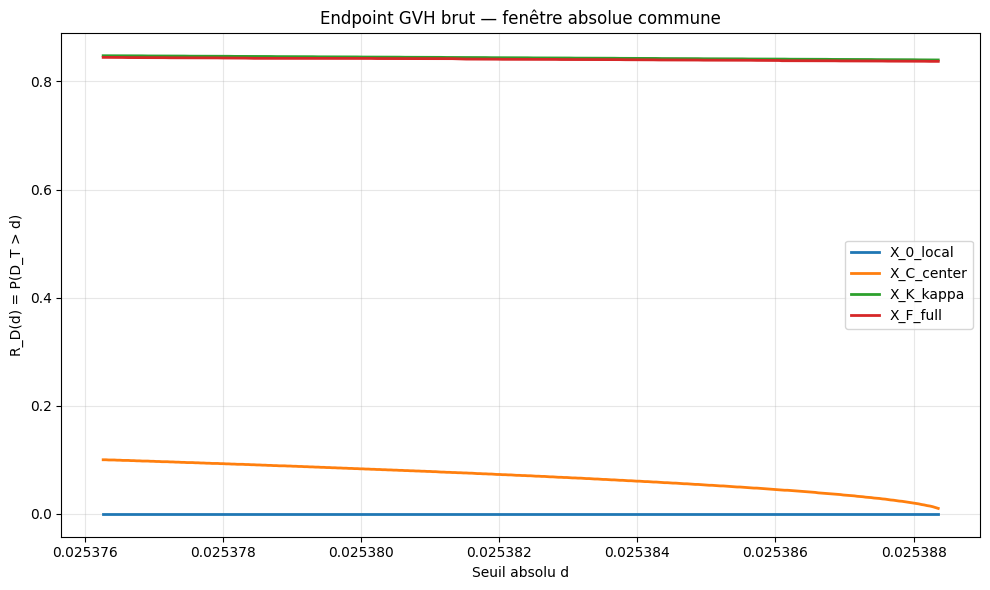

In [24]:
# ============================================================
# 13.1 — Endpoint GVH brut sur fenêtre absolue commune
# R_D(d) et A_tail_GVH
# ============================================================

R_D_GVH = {}
A_tail_GVH = {}

for name, D in D_frozen.items():

    R_D = empirical_survival(D, d_grid_GVH)
    R_D_GVH[name] = R_D

    A_tail = np.trapezoid(R_D, d_grid_GVH)
    A_tail_GVH[name] = A_tail


print("Endpoint GVH brut sur fenêtre commune définie par center_only :")
print("Cas          | R(d_L)      | R(d_U)      | A_tail_GVH")
print("-" * 70)

for name, R_D in R_D_GVH.items():
    print(
        f"{name:12s} | "
        f"{R_D[0]:.12f} | "
        f"{R_D[-1]:.12f} | "
        f"{A_tail_GVH[name]:.12e}"
    )


print("\nDifférences :")
print(
    "Full - Center = "
    f"{A_tail_GVH['X_F_full'] - A_tail_GVH['X_C_center']:.12e}"
)
print(
    "Full - Kappa  = "
    f"{A_tail_GVH['X_F_full'] - A_tail_GVH['X_K_kappa']:.12e}"
)
print(
    "Full - Local  = "
    f"{A_tail_GVH['X_F_full'] - A_tail_GVH['X_0_local']:.12e}"
)


# ============================================================
# Visualisation
# ============================================================

plt.figure(figsize=(10, 6))

for name, R_D in R_D_GVH.items():
    plt.plot(
        d_grid_GVH,
        R_D,
        linewidth=2,
        label=name
    )

plt.xlabel("Seuil absolu d")
plt.ylabel("R_D(d) = P(D_T > d)")
plt.title("Endpoint GVH brut — fenêtre absolue commune")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Fenêtre alternative définie par kappa_only :
d_L_K = Q90(kappa_only) = 0.026274290357
d_U_K = Q99(kappa_only) = 0.026327423095

Endpoint brut sur fenêtre kappa_only :
Cas          | R(d_L)      | R(d_U)      | A_tail_Kwindow
---------------------------------------------------------------------------
X_0_local    | 0.000000000000 | 0.000000000000 | 0.000000000000e+00
X_C_center   | 0.000000000000 | 0.000000000000 | 0.000000000000e+00
X_K_kappa    | 0.100020004001 | 0.010002000400 | 3.038520866286e-06
X_F_full     | 0.148029605921 | 0.115423084617 | 6.928490889661e-06

Différences :
Full - Kappa  = 3.889970023375e-06
Full - Center = 6.928490889661e-06
Full - Local  = 6.928490889661e-06


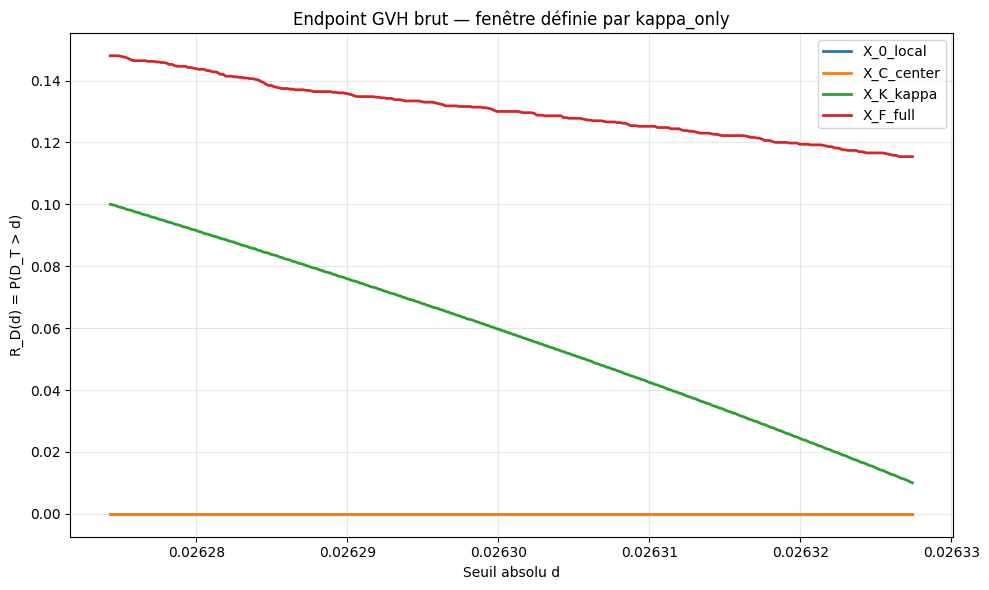

In [25]:
# ============================================================
# 13.1 — Fenêtre alternative définie par kappa_only
# Test de robustesse : full vs kappa
# ============================================================

D_ref_K = D_frozen["X_K_kappa"]

d_L_K = np.quantile(D_ref_K, 0.90)
d_U_K = np.quantile(D_ref_K, 0.99)

N_grid_K = 300
d_grid_K = np.linspace(d_L_K, d_U_K, N_grid_K)

R_D_Kwindow = {}
A_tail_Kwindow = {}

for name, D in D_frozen.items():
    R_D = empirical_survival(D, d_grid_K)
    R_D_Kwindow[name] = R_D
    A_tail_Kwindow[name] = np.trapezoid(R_D, d_grid_K)

print("Fenêtre alternative définie par kappa_only :")
print(f"d_L_K = Q90(kappa_only) = {d_L_K:.12f}")
print(f"d_U_K = Q99(kappa_only) = {d_U_K:.12f}")

print("\nEndpoint brut sur fenêtre kappa_only :")
print("Cas          | R(d_L)      | R(d_U)      | A_tail_Kwindow")
print("-" * 75)

for name, R_D in R_D_Kwindow.items():
    print(
        f"{name:12s} | "
        f"{R_D[0]:.12f} | "
        f"{R_D[-1]:.12f} | "
        f"{A_tail_Kwindow[name]:.12e}"
    )

print("\nDifférences :")
print(
    "Full - Kappa  = "
    f"{A_tail_Kwindow['X_F_full'] - A_tail_Kwindow['X_K_kappa']:.12e}"
)
print(
    "Full - Center = "
    f"{A_tail_Kwindow['X_F_full'] - A_tail_Kwindow['X_C_center']:.12e}"
)
print(
    "Full - Local  = "
    f"{A_tail_Kwindow['X_F_full'] - A_tail_Kwindow['X_0_local']:.12e}"
)

plt.figure(figsize=(10, 6))

for name, R_D in R_D_Kwindow.items():
    plt.plot(d_grid_K, R_D, linewidth=2, label=name)

plt.xlabel("Seuil absolu d")
plt.ylabel("R_D(d) = P(D_T > d)")
plt.title("Endpoint GVH brut — fenêtre définie par kappa_only")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# 13.1 — Distance L1 entre full et kappa_only
# sur les deux fenêtres déjà figées
# ============================================================

def L1_distance_survival(R1, R2, grid):
    return np.trapezoid(np.abs(R1 - R2), grid)


# Fenêtre 1 : définie par center_only
Delta_L1_FK_center_window = L1_distance_survival(
    R_D_GVH["X_F_full"],
    R_D_GVH["X_K_kappa"],
    d_grid_GVH
)

# Fenêtre 2 : définie par kappa_only
Delta_L1_FK_kappa_window = L1_distance_survival(
    R_D_Kwindow["X_F_full"],
    R_D_Kwindow["X_K_kappa"],
    d_grid_K
)


print("Distance L1 entre full et kappa_only :")
print(
    f"Fenêtre center_only : Δ_L1(F,K) = "
    f"{Delta_L1_FK_center_window:.12e}"
)
print(
    f"Fenêtre kappa_only  : Δ_L1(F,K) = "
    f"{Delta_L1_FK_kappa_window:.12e}"
)


# ============================================================
# Comparaison avec les aires déjà calculées
# ============================================================

print("\nRappel des différences d'aire :")
print(
    f"Fenêtre center_only : A_full - A_kappa = "
    f"{A_tail_GVH['X_F_full'] - A_tail_GVH['X_K_kappa']:.12e}"
)
print(
    f"Fenêtre kappa_only  : A_full - A_kappa = "
    f"{A_tail_Kwindow['X_F_full'] - A_tail_Kwindow['X_K_kappa']:.12e}"
)

Distance L1 entre full et kappa_only :
Fenêtre center_only : Δ_L1(F,K) = 3.343195809371e-08
Fenêtre kappa_only  : Δ_L1(F,K) = 3.889970023375e-06

Rappel des différences d'aire :
Fenêtre center_only : A_full - A_kappa = -3.343195809372e-08
Fenêtre kappa_only  : A_full - A_kappa = 3.889970023375e-06


## 13.2 — Bootstrap par blocs des endpoints figés

Objectif : tester si la séparation observée entre la forme complète \(X_F\) et la forme modulation seule \(X_K\) dépasse la variabilité induite par la dépendance temporelle et la taille finie de l’échantillon.

Les fenêtres sont figées avant bootstrap :

\[
W_C=[Q90(X_C),Q99(X_C)]
\]

\[
W_K=[Q90(X_K),Q99(X_K)]
\]

Elles ne sont pas recalculées dans les répliques bootstrap.

Les endpoints étudiés sont :

\[
\Delta A_{\rm tail}^{F-K}
=
A_{\rm tail}^{F}-A_{\rm tail}^{K}
\]

et

\[
\Delta_{L^1}(F,K)
=
\int |R_F(d)-R_K(d)|\,dd.
\]

Le rééchantillonnage se fait sur les séries temporelles \(D_T\), par blocs contigus, et non sur les courbes \(R_D(d)\).

Le bootstrap i.i.d. n’est pas utilisé comme protocole principal car les observations successives de \(D_T\) sont dépendantes.

Une sensibilité à la longueur de bloc est obligatoire :

\[
L/2,\quad L,\quad 2L.
\]

Critère provisoire :

- si le signe et l’ordre de grandeur de \(\Delta A_{\rm tail}^{F-K}\) restent stables, surtout sur \(W_K\), le signal localisé est considéré robuste au bootstrap par blocs ;
- sinon, le signal reste descriptif mais non inférentiel.

Cette étape ne démontre pas une loi physique. Elle teste seulement la robustesse de l’endpoint sous dépendance temporelle finie.

In [27]:
# ============================================================
# 13.2 — Paramètres du bootstrap par blocs
# ============================================================

B_boot = 1000
seed_boot = 20260707

L_base = 100
block_lengths = [50, 100, 200]

print("Paramètres bootstrap 13.2 :")
print(f"B_boot        = {B_boot}")
print(f"seed_boot     = {seed_boot}")
print(f"L_base        = {L_base}")
print(f"block_lengths = {block_lengths}")

print("\nFenêtres figées :")
print(f"W_C = [{d_L_GVH:.12f}, {d_U_GVH:.12f}]")
print(f"W_K = [{d_L_K:.12f}, {d_U_K:.12f}]")

Paramètres bootstrap 13.2 :
B_boot        = 1000
seed_boot     = 20260707
L_base        = 100
block_lengths = [50, 100, 200]

Fenêtres figées :
W_C = [0.025376266287, 0.025388356967]
W_K = [0.026274290357, 0.026327423095]


In [28]:
# ============================================================
# 13.2 — Moving Block Bootstrap
# Fonction de rééchantillonnage d'une série D_T
# ============================================================

def moving_block_bootstrap_series(D, L, rng):
    """
    Génère une réplique bootstrap d'une série temporelle D
    par Moving Block Bootstrap (MBB).

    Paramètres
    ----------
    D : array-like
        Série temporelle originale.
    L : int
        Longueur fixe des blocs contigus.
    rng : np.random.Generator
        Générateur aléatoire NumPy.

    Retour
    ------
    D_star : ndarray
        Série bootstrap de même longueur que D.
    """

    D = np.asarray(D)
    N = len(D)

    if L < 1:
        raise ValueError("L doit être >= 1.")

    if L > N:
        raise ValueError("L ne peut pas dépasser la longueur de la série.")

    # Nombre de positions possibles pour un bloc contigu
    n_starts = N - L + 1

    # Nombre de blocs nécessaires pour atteindre au moins N points
    n_blocks = int(np.ceil(N / L))

    # Tirage avec remise des positions de départ
    starts = rng.integers(
        low=0,
        high=n_starts,
        size=n_blocks
    )

    # Construction des blocs contigus
    blocks = [
        D[start:start + L]
        for start in starts
    ]

    # Concaténation puis troncature à la longueur originale N
    D_star = np.concatenate(blocks)[:N]

    return D_star

In [29]:
# ============================================================
# Vérification minimale de la fonction MBB
# ============================================================

rng_test = np.random.default_rng(seed_boot)

D_test = D_frozen["X_K_kappa"]

D_test_star = moving_block_bootstrap_series(
    D=D_test,
    L=L_base,
    rng=rng_test
)

print("Test Moving Block Bootstrap :")
print(f"Longueur originale  = {len(D_test)}")
print(f"Longueur bootstrap  = {len(D_test_star)}")
print(f"L utilisé           = {L_base}")

print("\nStatistiques descriptives :")
print(
    f"Original  : mean={D_test.mean():.12f} | "
    f"std={D_test.std():.12f}"
)
print(
    f"Bootstrap : mean={D_test_star.mean():.12f} | "
    f"std={D_test_star.std():.12f}"
)

Test Moving Block Bootstrap :
Longueur originale  = 4999
Longueur bootstrap  = 4999
L utilisé           = 100

Statistiques descriptives :
Original  : mean=0.025828211852 | std=0.000357066216
Bootstrap : mean=0.025849142581 | std=0.000358050875


In [30]:
# ============================================================
# 13.2 — Fonction endpoint F-K sur fenêtre figée
# ============================================================

def compute_FK_endpoints(D_F, D_K, d_grid_window):
    """
    Calcule les endpoints figés entre full et kappa_only
    sur une grille absolue commune.

    Retourne :
    - A_F
    - A_K
    - Delta_A = A_F - A_K
    - Delta_L1 = integral |R_F - R_K| dd
    """

    R_F = empirical_survival(D_F, d_grid_window)
    R_K = empirical_survival(D_K, d_grid_window)

    A_F = np.trapezoid(R_F, d_grid_window)
    A_K = np.trapezoid(R_K, d_grid_window)

    Delta_A = A_F - A_K
    Delta_L1 = np.trapezoid(np.abs(R_F - R_K), d_grid_window)

    return {
        "A_F": A_F,
        "A_K": A_K,
        "Delta_A": Delta_A,
        "Delta_L1": Delta_L1,
        "R_F": R_F,
        "R_K": R_K,
    }


# Vérification sur les séries originales, fenêtre K
endpoint_original_K = compute_FK_endpoints(
    D_F=D_frozen["X_F_full"],
    D_K=D_frozen["X_K_kappa"],
    d_grid_window=d_grid_K
)

print("Endpoint original sur fenêtre K :")
print(f"A_F      = {endpoint_original_K['A_F']:.12e}")
print(f"A_K      = {endpoint_original_K['A_K']:.12e}")
print(f"Delta_A  = {endpoint_original_K['Delta_A']:.12e}")
print(f"Delta_L1 = {endpoint_original_K['Delta_L1']:.12e}")

Endpoint original sur fenêtre K :
A_F      = 6.928490889661e-06
A_K      = 3.038520866286e-06
Delta_A  = 3.889970023375e-06
Delta_L1 = 3.889970023375e-06


In [31]:
# ============================================================
# 13.2 — Bootstrap MBB initial sur fenêtre K, L=100
# ============================================================

rng_boot = np.random.default_rng(seed_boot)

D_F_original = D_frozen["X_F_full"]
D_K_original = D_frozen["X_K_kappa"]

L_test = 100

Delta_A_boot_K_L100 = np.empty(B_boot)
Delta_L1_boot_K_L100 = np.empty(B_boot)

for b in range(B_boot):

    D_F_star = moving_block_bootstrap_series(
        D=D_F_original,
        L=L_test,
        rng=rng_boot
    )

    D_K_star = moving_block_bootstrap_series(
        D=D_K_original,
        L=L_test,
        rng=rng_boot
    )

    endpoint_star = compute_FK_endpoints(
        D_F=D_F_star,
        D_K=D_K_star,
        d_grid_window=d_grid_K
    )

    Delta_A_boot_K_L100[b] = endpoint_star["Delta_A"]
    Delta_L1_boot_K_L100[b] = endpoint_star["Delta_L1"]


print("Bootstrap MBB — fenêtre K, L=100")
print(f"B_boot = {B_boot}")

print("\nDelta_A = A_F - A_K")
print(f"Original = {endpoint_original_K['Delta_A']:.12e}")
print(f"Mean boot = {Delta_A_boot_K_L100.mean():.12e}")
print(f"Std boot  = {Delta_A_boot_K_L100.std(ddof=1):.12e}")
print(f"CI 95%    = [{np.percentile(Delta_A_boot_K_L100, 2.5):.12e}, "
      f"{np.percentile(Delta_A_boot_K_L100, 97.5):.12e}]")

print("\nDelta_L1 = integral |R_F - R_K| dd")
print(f"Original = {endpoint_original_K['Delta_L1']:.12e}")
print(f"Mean boot = {Delta_L1_boot_K_L100.mean():.12e}")
print(f"Std boot  = {Delta_L1_boot_K_L100.std(ddof=1):.12e}")
print(f"CI 95%    = [{np.percentile(Delta_L1_boot_K_L100, 2.5):.12e}, "
      f"{np.percentile(Delta_L1_boot_K_L100, 97.5):.12e}]")

Bootstrap MBB — fenêtre K, L=100
B_boot = 1000

Delta_A = A_F - A_K
Original = 3.889970023375e-06
Mean boot = 4.122987209945e-06
Std boot  = 2.350273975519e-06
CI 95%    = [-5.173844444371e-07, 8.858995666962e-06]

Delta_L1 = integral |R_F - R_K| dd
Original = 3.889970023375e-06
Mean boot = 4.310800559967e-06
Std boot  = 2.068189441096e-06
CI 95%    = [1.228735956376e-06, 8.858995666962e-06]


In [32]:
# ============================================================
# 13.2 — Sensibilité à la longueur de bloc
# Fenêtre K, L = 50, 100, 200
# ============================================================

bootstrap_sensitivity_K = {}

for L in block_lengths:

    rng_L = np.random.default_rng(seed_boot + L)

    Delta_A_boot = np.empty(B_boot)
    Delta_L1_boot = np.empty(B_boot)

    for b in range(B_boot):

        D_F_star = moving_block_bootstrap_series(
            D=D_F_original,
            L=L,
            rng=rng_L
        )

        D_K_star = moving_block_bootstrap_series(
            D=D_K_original,
            L=L,
            rng=rng_L
        )

        endpoint_star = compute_FK_endpoints(
            D_F=D_F_star,
            D_K=D_K_star,
            d_grid_window=d_grid_K
        )

        Delta_A_boot[b] = endpoint_star["Delta_A"]
        Delta_L1_boot[b] = endpoint_star["Delta_L1"]

    bootstrap_sensitivity_K[L] = {
        "Delta_A": Delta_A_boot,
        "Delta_L1": Delta_L1_boot,
    }


print("Sensibilité MBB — fenêtre K")
print("L | Mean ΔA | CI95 ΔA low | CI95 ΔA high | Mean ΔL1 | CI95 ΔL1 low | CI95 ΔL1 high")
print("-" * 115)

for L in block_lengths:

    DA = bootstrap_sensitivity_K[L]["Delta_A"]
    DL1 = bootstrap_sensitivity_K[L]["Delta_L1"]

    print(
        f"{L:3d} | "
        f"{DA.mean():.6e} | "
        f"{np.percentile(DA, 2.5):.6e} | "
        f"{np.percentile(DA, 97.5):.6e} | "
        f"{DL1.mean():.6e} | "
        f"{np.percentile(DL1, 2.5):.6e} | "
        f"{np.percentile(DL1, 97.5):.6e}"
    )

Sensibilité MBB — fenêtre K
L | Mean ΔA | CI95 ΔA low | CI95 ΔA high | Mean ΔL1 | CI95 ΔL1 low | CI95 ΔL1 high
-------------------------------------------------------------------------------------------------------------------
 50 | 3.873350e-06 | 3.695575e-07 | 7.436613e-06 | 3.941003e-06 | 1.159113e-06 | 7.436613e-06
100 | 3.885655e-06 | -9.931202e-07 | 8.510581e-06 | 4.146480e-06 | 1.116048e-06 | 8.510581e-06
200 | 4.322901e-06 | -9.645388e-07 | 9.147370e-06 | 4.602854e-06 | 1.209729e-06 | 9.147370e-06


In [33]:
# ============================================================
# 13.2 — Sensibilité à la longueur de bloc
# Fenêtre C, L = 50, 100, 200
# ============================================================

bootstrap_sensitivity_C = {}

for L in block_lengths:

    rng_L = np.random.default_rng(seed_boot + 1000 + L)

    Delta_A_boot = np.empty(B_boot)
    Delta_L1_boot = np.empty(B_boot)

    for b in range(B_boot):

        D_F_star = moving_block_bootstrap_series(
            D=D_F_original,
            L=L,
            rng=rng_L
        )

        D_K_star = moving_block_bootstrap_series(
            D=D_K_original,
            L=L,
            rng=rng_L
        )

        endpoint_star = compute_FK_endpoints(
            D_F=D_F_star,
            D_K=D_K_star,
            d_grid_window=d_grid_GVH   # fenêtre W_C
        )

        Delta_A_boot[b] = endpoint_star["Delta_A"]
        Delta_L1_boot[b] = endpoint_star["Delta_L1"]

    bootstrap_sensitivity_C[L] = {
        "Delta_A": Delta_A_boot,
        "Delta_L1": Delta_L1_boot,
    }


print("Sensibilité MBB — fenêtre C")
print("L | Mean ΔA | CI95 ΔA low | CI95 ΔA high | Mean ΔL1 | CI95 ΔL1 low | CI95 ΔL1 high")
print("-" * 115)

for L in block_lengths:

    DA = bootstrap_sensitivity_C[L]["Delta_A"]
    DL1 = bootstrap_sensitivity_C[L]["Delta_L1"]

    print(
        f"{L:3d} | "
        f"{DA.mean():.6e} | "
        f"{np.percentile(DA, 2.5):.6e} | "
        f"{np.percentile(DA, 97.5):.6e} | "
        f"{DL1.mean():.6e} | "
        f"{np.percentile(DL1, 2.5):.6e} | "
        f"{np.percentile(DL1, 97.5):.6e}"
    )

Sensibilité MBB — fenêtre C
L | Mean ΔA | CI95 ΔA low | CI95 ΔA high | Mean ΔL1 | CI95 ΔL1 low | CI95 ΔL1 high
-------------------------------------------------------------------------------------------------------------------
 50 | -4.647940e-08 | -1.184074e-06 | 1.062595e-06 | 4.508083e-07 | 2.326647e-08 | 1.267821e-06
100 | -9.516271e-08 | -1.601919e-06 | 1.522052e-06 | 6.531183e-07 | 3.619891e-08 | 1.719053e-06
200 | -5.389850e-08 | -1.912376e-06 | 1.968140e-06 | 8.010134e-07 | 4.573426e-08 | 2.212637e-06


In [34]:
# ============================================================
# 13.2 — Contraste apparié entre fenêtres
# Gamma_L1 = Delta_L1(W_K) - Delta_L1(W_C)
# L = 50, 100, 200
# ============================================================

bootstrap_gamma_L1 = {}

for L in block_lengths:

    rng_L = np.random.default_rng(seed_boot + 2000 + L)

    Gamma_L1_boot = np.empty(B_boot)

    for b in range(B_boot):

        D_F_star = moving_block_bootstrap_series(
            D=D_F_original,
            L=L,
            rng=rng_L
        )

        D_K_star = moving_block_bootstrap_series(
            D=D_K_original,
            L=L,
            rng=rng_L
        )

        endpoint_K = compute_FK_endpoints(
            D_F=D_F_star,
            D_K=D_K_star,
            d_grid_window=d_grid_K
        )

        endpoint_C = compute_FK_endpoints(
            D_F=D_F_star,
            D_K=D_K_star,
            d_grid_window=d_grid_GVH
        )

        Gamma_L1_boot[b] = (
            endpoint_K["Delta_L1"]
            - endpoint_C["Delta_L1"]
        )

    bootstrap_gamma_L1[L] = Gamma_L1_boot


print("Contraste apparié entre fenêtres : Gamma_L1 = Delta_L1(W_K) - Delta_L1(W_C)")
print("L | Mean Gamma | CI95 low | CI95 high | P(Gamma > 0)")
print("-" * 80)

for L in block_lengths:

    G = bootstrap_gamma_L1[L]

    print(
        f"{L:3d} | "
        f"{G.mean():.6e} | "
        f"{np.percentile(G, 2.5):.6e} | "
        f"{np.percentile(G, 97.5):.6e} | "
        f"{np.mean(G > 0):.6f}"
    )

Contraste apparié entre fenêtres : Gamma_L1 = Delta_L1(W_K) - Delta_L1(W_C)
L | Mean Gamma | CI95 low | CI95 high | P(Gamma > 0)
--------------------------------------------------------------------------------
 50 | 3.595682e-06 | 7.065109e-07 | 7.264255e-06 | 0.997000
100 | 3.597581e-06 | 3.000812e-07 | 8.080600e-06 | 0.981000
200 | 4.075869e-06 | 5.882813e-08 | 8.742788e-06 | 0.981000


In [35]:
# ============================================================
# 13.2B — Moving Block Bootstrap avec positions de couture
# ============================================================

def moving_block_bootstrap_series_with_seams(D, L, rng):
    """
    Moving Block Bootstrap avec suivi des coutures.

    Retourne :
    - D_star : série bootstrap
    - seam_positions : indices dans D_star correspondant aux jonctions
      entre deux blocs concaténés.
    """

    D = np.asarray(D)
    N = len(D)

    if L < 1:
        raise ValueError("L doit être >= 1.")
    if L > N:
        raise ValueError("L ne peut pas dépasser N.")

    n_starts = N - L + 1
    n_blocks = int(np.ceil(N / L))

    starts = rng.integers(
        low=0,
        high=n_starts,
        size=n_blocks
    )

    blocks = [D[start:start + L] for start in starts]

    D_star_full = np.concatenate(blocks)
    D_star = D_star_full[:N]

    # Les coutures apparaissent aux positions L, 2L, 3L, ...
    seam_positions = np.arange(L, n_blocks * L, L)
    seam_positions = seam_positions[seam_positions < N]

    return D_star, seam_positions


# ============================================================
# Vérification minimale
# ============================================================

rng_test = np.random.default_rng(seed_boot)

D_test_star, seams_test = moving_block_bootstrap_series_with_seams(
    D=D_frozen["X_K_kappa"],
    L=100,
    rng=rng_test
)

print("Test MBB avec coutures :")
print(f"Longueur bootstrap = {len(D_test_star)}")
print(f"Nombre de coutures = {len(seams_test)}")
print(f"Premières coutures = {seams_test[:10]}")

Test MBB avec coutures :
Longueur bootstrap = 4999
Nombre de coutures = 49
Premières coutures = [ 100  200  300  400  500  600  700  800  900 1000]


In [36]:
# ============================================================
# 13.2B — Diagnostic couture / dépassements dans W_K
# ============================================================

def seam_proximity_mask(N, seam_positions, radius=1):
    """
    Marque les points situés à distance <= radius d'une couture.
    """
    mask = np.zeros(N, dtype=bool)

    for s in seam_positions:
        left = max(0, s - radius)
        right = min(N, s + radius + 1)
        mask[left:right] = True

    return mask


def seam_exceedance_diagnostic(D_star, seam_positions, threshold, radius=1):
    """
    Diagnostic : les dépassements D_star > threshold
    sont-ils proches des coutures ?
    """
    N = len(D_star)

    seam_mask = seam_proximity_mask(
        N=N,
        seam_positions=seam_positions,
        radius=radius
    )

    exceed_mask = D_star > threshold

    n_exceed = exceed_mask.sum()
    n_exceed_near_seam = np.sum(exceed_mask & seam_mask)

    if n_exceed > 0:
        frac_exceed_near_seam = n_exceed_near_seam / n_exceed
    else:
        frac_exceed_near_seam = np.nan

    frac_all_near_seam = seam_mask.mean()

    return {
        "n_exceed": n_exceed,
        "n_exceed_near_seam": n_exceed_near_seam,
        "frac_exceed_near_seam": frac_exceed_near_seam,
        "frac_all_near_seam": frac_all_near_seam,
    }


# Test sur une réplique K, seuil haut W_K = d_L_K
diag_test = seam_exceedance_diagnostic(
    D_star=D_test_star,
    seam_positions=seams_test,
    threshold=d_L_K,
    radius=1
)

print("Diagnostic couture — test unique K, seuil d_L_K :")
for key, value in diag_test.items():
    print(f"{key:24s} = {value}")

Diagnostic couture — test unique K, seuil d_L_K :
n_exceed                 = 647
n_exceed_near_seam       = 18
frac_exceed_near_seam    = 0.027820710973724884
frac_all_near_seam       = 0.029405881176235247


In [37]:
# ============================================================
# 13.2B — Diagnostic couture sur B=1000 répliques
# L = 50, 100, 200
# Fenêtre W_K, seuil d_L_K
# ============================================================

seam_diagnostics = {}

for L in block_lengths:
    rng_L = np.random.default_rng(seed_boot + 3000 + L)

    ratios_K = []
    ratios_F = []
    baseline_rates = []

    for b in range(B_boot):

        D_K_star, seams_K = moving_block_bootstrap_series_with_seams(
            D=D_K_original,
            L=L,
            rng=rng_L
        )

        D_F_star, seams_F = moving_block_bootstrap_series_with_seams(
            D=D_F_original,
            L=L,
            rng=rng_L
        )

        diag_K = seam_exceedance_diagnostic(
            D_star=D_K_star,
            seam_positions=seams_K,
            threshold=d_L_K,
            radius=1
        )

        diag_F = seam_exceedance_diagnostic(
            D_star=D_F_star,
            seam_positions=seams_F,
            threshold=d_L_K,
            radius=1
        )

        ratios_K.append(diag_K["frac_exceed_near_seam"])
        ratios_F.append(diag_F["frac_exceed_near_seam"])
        baseline_rates.append(diag_K["frac_all_near_seam"])

    seam_diagnostics[L] = {
        "K": np.array(ratios_K),
        "F": np.array(ratios_F),
        "baseline": np.array(baseline_rates),
    }


print("Diagnostic couture — dépassements W_K proches des coutures")
print("L | baseline | K mean | K CI95 | F mean | F CI95")
print("-" * 90)

for L in block_lengths:
    K = seam_diagnostics[L]["K"]
    F = seam_diagnostics[L]["F"]
    B0 = seam_diagnostics[L]["baseline"]

    print(
        f"{L:3d} | "
        f"{np.nanmean(B0):.6f} | "
        f"{np.nanmean(K):.6f} | "
        f"[{np.nanpercentile(K, 2.5):.6f}, {np.nanpercentile(K, 97.5):.6f}] | "
        f"{np.nanmean(F):.6f} | "
        f"[{np.nanpercentile(F, 2.5):.6f}, {np.nanpercentile(F, 97.5):.6f}]"
    )

Diagnostic couture — dépassements W_K proches des coutures
L | baseline | K mean | K CI95 | F mean | F CI95
------------------------------------------------------------------------------------------
 50 | 0.059412 | 0.058468 | [0.052629, 0.062092] | 0.059193 | [0.049842, 0.071686]
100 | 0.029406 | 0.028185 | [0.020941, 0.032942] | 0.029889 | [0.020182, 0.043292]
200 | 0.014403 | 0.013956 | [0.006076, 0.019378] | 0.014910 | [0.005126, 0.029092]


## 13.2C — Split-sample temporel

Objectif : contrôler le risque de sélection post hoc des fenêtres \(W_C\) et \(W_K\).

La série temporelle \(D_T\) est divisée en deux moitiés contiguës :

\[
H_1 = \text{première moitié}
\]

\[
H_2 = \text{seconde moitié}
\]

La moitié \(H_1\) sert uniquement à définir les fenêtres candidates.

La moitié \(H_2\) sert uniquement à confirmer le contraste :

\[
\Gamma_{L^1}
=
\Delta_{L^1}^{W_K}
-
\Delta_{L^1}^{W_C}.
\]

Aucune fenêtre ne sera recalculée après inspection de \(H_2\).

In [38]:
# ============================================================
# 13.2C — Split-sample temporel
# ============================================================

N_D = len(D_frozen["X_K_kappa"])
split_idx = N_D // 2

D_split = {}

for name, D in D_frozen.items():
    D_split[name] = {
        "H1": D[:split_idx],
        "H2": D[split_idx:]
    }

print("Split temporel :")
print(f"N_D       = {N_D}")
print(f"split_idx = {split_idx}")

for name in D_frozen.keys():
    print(
        f"{name:12s} | "
        f"H1={len(D_split[name]['H1'])} | "
        f"H2={len(D_split[name]['H2'])}"
    )

Split temporel :
N_D       = 4999
split_idx = 2499
X_0_local    | H1=2499 | H2=2500
X_C_center   | H1=2499 | H2=2500
X_K_kappa    | H1=2499 | H2=2500
X_F_full     | H1=2499 | H2=2500


In [39]:
# ============================================================
# 13.2C — Fenêtres définies uniquement sur H1
# ============================================================

D_C_H1 = D_split["X_C_center"]["H1"]
D_K_H1 = D_split["X_K_kappa"]["H1"]

W_C_H1 = (
    np.quantile(D_C_H1, 0.90),
    np.quantile(D_C_H1, 0.99)
)

W_K_H1 = (
    np.quantile(D_K_H1, 0.90),
    np.quantile(D_K_H1, 0.99)
)

N_grid_split = 300

d_grid_C_H1 = np.linspace(W_C_H1[0], W_C_H1[1], N_grid_split)
d_grid_K_H1 = np.linspace(W_K_H1[0], W_K_H1[1], N_grid_split)

print("Fenêtres définies sur H1 seulement :")
print(f"W_C_H1 = [{W_C_H1[0]:.12f}, {W_C_H1[1]:.12f}]")
print(f"W_K_H1 = [{W_K_H1[0]:.12f}, {W_K_H1[1]:.12f}]")
print(f"N_grid_split = {N_grid_split}")

print("\nImportant : ces fenêtres seront appliquées à H2 sans recalcul.")

Fenêtres définies sur H1 seulement :
W_C_H1 = [0.025376266287, 0.025388356967]
W_K_H1 = [0.025810339106, 0.025869213641]
N_grid_split = 300

Important : ces fenêtres seront appliquées à H2 sans recalcul.


In [40]:
# ============================================================
# 13.2C — Confirmation sur H2 uniquement
# Fenêtres définies sur H1, appliquées sans recalcul à H2
# ============================================================

D_F_H2 = D_split["X_F_full"]["H2"]
D_K_H2 = D_split["X_K_kappa"]["H2"]

endpoint_K_H2 = compute_FK_endpoints(
    D_F=D_F_H2,
    D_K=D_K_H2,
    d_grid_window=d_grid_K_H1
)

endpoint_C_H2 = compute_FK_endpoints(
    D_F=D_F_H2,
    D_K=D_K_H2,
    d_grid_window=d_grid_C_H1
)

Gamma_L1_H2 = (
    endpoint_K_H2["Delta_L1"]
    - endpoint_C_H2["Delta_L1"]
)

print("Split-sample confirmation sur H2 :")
print("\nFenêtre W_K définie sur H1 :")
print(f"Delta_A_K_H2  = {endpoint_K_H2['Delta_A']:.12e}")
print(f"Delta_L1_K_H2 = {endpoint_K_H2['Delta_L1']:.12e}")

print("\nFenêtre W_C définie sur H1 :")
print(f"Delta_A_C_H2  = {endpoint_C_H2['Delta_A']:.12e}")
print(f"Delta_L1_C_H2 = {endpoint_C_H2['Delta_L1']:.12e}")

print("\nContraste confirmé sur H2 :")
print(f"Gamma_L1_H2 = {Gamma_L1_H2:.12e}")

Split-sample confirmation sur H2 :

Fenêtre W_K définie sur H1 :
Delta_A_K_H2  = -6.242039663286e-06
Delta_L1_K_H2 = 6.242039663286e-06

Fenêtre W_C définie sur H1 :
Delta_A_C_H2  = 0.000000000000e+00
Delta_L1_C_H2 = 0.000000000000e+00

Contraste confirmé sur H2 :
Gamma_L1_H2 = 6.242039663286e-06


In [41]:
# ============================================================
# 13.2D — Diagnostic rapide de phase de kappa(t)
# ============================================================

phase_kappa = Omega * t[:-1]  # même longueur que D_T : 4999

sin_phase = np.sin(phase_kappa)
cos_phase = np.cos(phase_kappa)

sin_H1 = sin_phase[:split_idx]
sin_H2 = sin_phase[split_idx:]

cos_H1 = cos_phase[:split_idx]
cos_H2 = cos_phase[split_idx:]

print("Diagnostic phase kappa :")
print(f"mean sin H1 = {sin_H1.mean():.12f}")
print(f"mean sin H2 = {sin_H2.mean():.12f}")
print(f"mean cos H1 = {cos_H1.mean():.12f}")
print(f"mean cos H2 = {cos_H2.mean():.12f}")

print("\nDifférences H2 - H1 :")
print(f"Delta mean sin = {sin_H2.mean() - sin_H1.mean():.12f}")
print(f"Delta mean cos = {cos_H2.mean() - cos_H1.mean():.12f}")

# Valeur moyenne de kappa sur chaque moitié
kappa_DT = kappa[:-1]

kappa_H1 = kappa_DT[:split_idx]
kappa_H2 = kappa_DT[split_idx:]

print("\nKappa moyen :")
print(f"mean kappa H1 = {kappa_H1.mean():.12f}")
print(f"mean kappa H2 = {kappa_H2.mean():.12f}")
print(f"Delta kappa H2-H1 = {kappa_H2.mean() - kappa_H1.mean():.12f}")

Diagnostic phase kappa :
mean sin H1 = 0.303784530757
mean sin H2 = 0.795660428617
mean cos H1 = 0.935552773157
mean cos H2 = 0.578310363174

Différences H2 - H1 :
Delta mean sin = 0.491875897860
Delta mean cos = -0.357242409984

Kappa moyen :
mean kappa H1 = 1.015189226538
mean kappa H2 = 1.039783021431
Delta kappa H2-H1 = 0.024593794893


In [42]:
# ============================================================
# 13.2E — Split alternatif pair / impair
# ============================================================

D_split_even_odd = {}

for name, D in D_frozen.items():
    D_split_even_odd[name] = {
        "even": D[::2],
        "odd": D[1::2],
    }

print("Split pair / impair :")
for name in D_frozen.keys():
    print(
        f"{name:12s} | "
        f"even={len(D_split_even_odd[name]['even'])} | "
        f"odd={len(D_split_even_odd[name]['odd'])}"
    )


# Diagnostic phase pair / impair
sin_even = sin_phase[::2]
sin_odd = sin_phase[1::2]

kappa_even = kappa_DT[::2]
kappa_odd = kappa_DT[1::2]

print("\nDiagnostic phase pair / impair :")
print(f"mean sin even = {sin_even.mean():.12f}")
print(f"mean sin odd  = {sin_odd.mean():.12f}")
print(f"Delta sin odd-even = {sin_odd.mean() - sin_even.mean():.12e}")

print(f"mean kappa even = {kappa_even.mean():.12f}")
print(f"mean kappa odd  = {kappa_odd.mean():.12f}")
print(f"Delta kappa odd-even = {kappa_odd.mean() - kappa_even.mean():.12e}")

Split pair / impair :
X_0_local    | even=2500 | odd=2499
X_C_center   | even=2500 | odd=2499
X_K_kappa    | even=2500 | odd=2499
X_F_full     | even=2500 | odd=2499

Diagnostic phase pair / impair :
mean sin even = 0.549756811980
mean sin odd  = 0.549786548202
Delta sin odd-even = 2.973622178826e-05
mean kappa even = 1.027487840599
mean kappa odd  = 1.027489327410
Delta kappa odd-even = 1.486811089357e-06


In [43]:
# ============================================================
# 13.2E — Fenêtres définies sur even, confirmation sur odd
# ============================================================

D_C_even = D_split_even_odd["X_C_center"]["even"]
D_K_even = D_split_even_odd["X_K_kappa"]["even"]

W_C_even = (
    np.quantile(D_C_even, 0.90),
    np.quantile(D_C_even, 0.99)
)

W_K_even = (
    np.quantile(D_K_even, 0.90),
    np.quantile(D_K_even, 0.99)
)

d_grid_C_even = np.linspace(W_C_even[0], W_C_even[1], N_grid_split)
d_grid_K_even = np.linspace(W_K_even[0], W_K_even[1], N_grid_split)

print("Fenêtres définies sur even seulement :")
print(f"W_C_even = [{W_C_even[0]:.12f}, {W_C_even[1]:.12f}]")
print(f"W_K_even = [{W_K_even[0]:.12f}, {W_K_even[1]:.12f}]")

# Confirmation sur odd
D_F_odd = D_split_even_odd["X_F_full"]["odd"]
D_K_odd = D_split_even_odd["X_K_kappa"]["odd"]

endpoint_K_odd = compute_FK_endpoints(
    D_F=D_F_odd,
    D_K=D_K_odd,
    d_grid_window=d_grid_K_even
)

endpoint_C_odd = compute_FK_endpoints(
    D_F=D_F_odd,
    D_K=D_K_odd,
    d_grid_window=d_grid_C_even
)

Gamma_L1_odd = endpoint_K_odd["Delta_L1"] - endpoint_C_odd["Delta_L1"]

print("\nConfirmation sur odd :")
print(f"Delta_L1_K_odd = {endpoint_K_odd['Delta_L1']:.12e}")
print(f"Delta_L1_C_odd = {endpoint_C_odd['Delta_L1']:.12e}")
print(f"Gamma_L1_odd   = {Gamma_L1_odd:.12e}")

print("\nContrastes signés :")
print(f"Delta_A_K_odd = {endpoint_K_odd['Delta_A']:.12e}")
print(f"Delta_A_C_odd = {endpoint_C_odd['Delta_A']:.12e}")

Fenêtres définies sur even seulement :
W_C_even = [0.025376275848, 0.025388376034]
W_K_even = [0.026274290350, 0.026327423094]

Confirmation sur odd :
Delta_L1_K_odd = 3.892010985298e-06
Delta_L1_C_odd = 3.506814417682e-08
Gamma_L1_odd   = 3.856942841121e-06

Contrastes signés :
Delta_A_K_odd = 3.892010985298e-06
Delta_A_C_odd = -3.506814417682e-08


In [44]:
# ============================================================
# 13.2F — Split par blocs alternés
# Blocs contigus de longueur 250 : A/B/A/B/...
# ============================================================

block_split_L = 250
N_D = len(D_frozen["X_K_kappa"])

block_ids = np.arange(N_D) // block_split_L

mask_A = (block_ids % 2 == 0)
mask_B = (block_ids % 2 == 1)

D_split_blocks = {}

for name, D in D_frozen.items():
    D_split_blocks[name] = {
        "A": D[mask_A],
        "B": D[mask_B],
    }

print("Split par blocs alternés :")
print(f"block_split_L = {block_split_L}")
print(f"N_A = {mask_A.sum()}")
print(f"N_B = {mask_B.sum()}")

for name in D_frozen.keys():
    print(
        f"{name:12s} | "
        f"A={len(D_split_blocks[name]['A'])} | "
        f"B={len(D_split_blocks[name]['B'])}"
    )

# Diagnostic phase A/B
sin_A = sin_phase[mask_A]
sin_B = sin_phase[mask_B]

kappa_A = kappa_DT[mask_A]
kappa_B = kappa_DT[mask_B]

print("\nDiagnostic phase blocs alternés :")
print(f"mean sin A = {sin_A.mean():.12f}")
print(f"mean sin B = {sin_B.mean():.12f}")
print(f"Delta sin B-A = {sin_B.mean() - sin_A.mean():.12e}")

print(f"mean kappa A = {kappa_A.mean():.12f}")
print(f"mean kappa B = {kappa_B.mean():.12f}")
print(f"Delta kappa B-A = {kappa_B.mean() - kappa_A.mean():.12e}")

Split par blocs alternés :
block_split_L = 250
N_A = 2500
N_B = 2499
X_0_local    | A=2500 | B=2499
X_C_center   | A=2500 | B=2499
X_K_kappa    | A=2500 | B=2499
X_F_full     | A=2500 | B=2499

Diagnostic phase blocs alternés :
mean sin A = 0.526063578379
mean sin B = 0.573489262888
Delta sin B-A = 4.742568450881e-02
mean kappa A = 1.026303178919
mean kappa B = 1.028674463144
Delta kappa B-A = 2.371284225441e-03


In [45]:
# ============================================================
# 13.2F — Fenêtres sur blocs A, confirmation sur blocs B
# ============================================================

D_C_A = D_split_blocks["X_C_center"]["A"]
D_K_A = D_split_blocks["X_K_kappa"]["A"]

W_C_A = (
    np.quantile(D_C_A, 0.90),
    np.quantile(D_C_A, 0.99)
)

W_K_A = (
    np.quantile(D_K_A, 0.90),
    np.quantile(D_K_A, 0.99)
)

d_grid_C_A = np.linspace(W_C_A[0], W_C_A[1], N_grid_split)
d_grid_K_A = np.linspace(W_K_A[0], W_K_A[1], N_grid_split)

print("Fenêtres définies sur blocs A seulement :")
print(f"W_C_A = [{W_C_A[0]:.12f}, {W_C_A[1]:.12f}]")
print(f"W_K_A = [{W_K_A[0]:.12f}, {W_K_A[1]:.12f}]")

# Confirmation sur blocs B
D_F_B = D_split_blocks["X_F_full"]["B"]
D_K_B = D_split_blocks["X_K_kappa"]["B"]

endpoint_K_B = compute_FK_endpoints(
    D_F=D_F_B,
    D_K=D_K_B,
    d_grid_window=d_grid_K_A
)

endpoint_C_B = compute_FK_endpoints(
    D_F=D_F_B,
    D_K=D_K_B,
    d_grid_window=d_grid_C_A
)

Gamma_L1_B = endpoint_K_B["Delta_L1"] - endpoint_C_B["Delta_L1"]

print("\nConfirmation sur blocs B :")
print(f"Delta_L1_K_B = {endpoint_K_B['Delta_L1']:.12e}")
print(f"Delta_L1_C_B = {endpoint_C_B['Delta_L1']:.12e}")
print(f"Gamma_L1_B   = {Gamma_L1_B:.12e}")

print("\nContrastes signés :")
print(f"Delta_A_K_B = {endpoint_K_B['Delta_A']:.12e}")
print(f"Delta_A_C_B = {endpoint_C_B['Delta_A']:.12e}")

Fenêtres définies sur blocs A seulement :
W_C_A = [0.025376256614, 0.025388356869]
W_K_A = [0.026242149699, 0.026302825484]

Confirmation sur blocs B :
Delta_L1_K_B = 2.475628778035e-06
Delta_L1_C_B = 3.070160359546e-07
Gamma_L1_B   = 2.168612742081e-06

Contrastes signés :
Delta_A_K_B = 2.433321442219e-06
Delta_A_C_B = -3.070160359546e-07


### 13.2F — Résultat multi-split figé

Trois schémas de split ont été testés :

1. split temporel \(H_1 \to H_2\) ;
2. split pair \(\to\) impair ;
3. split par blocs alternés \(A \to B\), blocs de longueur 250.

Dans les trois cas, les fenêtres sont définies sur la partie d’exploration puis appliquées sans recalcul à la partie de confirmation.

Résultat commun :

\[
\Gamma_{L^1}
=
\Delta_{L^1}^{W_K}(F,K)
-
\Delta_{L^1}^{W_C}(F,K)
>0.
\]

Ce résultat est désormais figé comme robustesse interne multi-split.

Limite : les trois splits proviennent encore de la même trajectoire déterministe.

In [46]:
# ============================================================
# 13.2G — MBB interne à la partie de confirmation B
# Fenêtres W_C^A et W_K^A strictement figées
# ============================================================

# Séries de confirmation B
D_F_B = np.asarray(D_split_blocks["X_F_full"]["B"])
D_K_B = np.asarray(D_split_blocks["X_K_kappa"]["B"])

# IMPORTANT :
# Les grilles ont été définies sur A et ne sont jamais recalculées ici.
grid_C_fixed = np.asarray(d_grid_C_A)
grid_K_fixed = np.asarray(d_grid_K_A)

# Stockage des résultats
mbb_B_results = {}

for L in block_lengths:

    rng_L = np.random.default_rng(seed_boot + 7000 + L)

    Delta_A_K_boot = np.empty(B_boot)
    Delta_L1_K_boot = np.empty(B_boot)

    Delta_A_C_boot = np.empty(B_boot)
    Delta_L1_C_boot = np.empty(B_boot)

    Gamma_L1_boot = np.empty(B_boot)

    for b in range(B_boot):

        # Rééchantillonnage MBB interne à B uniquement
        D_F_B_star = moving_block_bootstrap_series(
            D=D_F_B,
            L=L,
            rng=rng_L
        )

        D_K_B_star = moving_block_bootstrap_series(
            D=D_K_B,
            L=L,
            rng=rng_L
        )

        # Endpoint sur fenêtre K définie sur A
        ep_K = compute_FK_endpoints(
            D_F=D_F_B_star,
            D_K=D_K_B_star,
            d_grid_window=grid_K_fixed
        )

        # Endpoint sur fenêtre C définie sur A
        ep_C = compute_FK_endpoints(
            D_F=D_F_B_star,
            D_K=D_K_B_star,
            d_grid_window=grid_C_fixed
        )

        Delta_A_K_boot[b] = ep_K["Delta_A"]
        Delta_L1_K_boot[b] = ep_K["Delta_L1"]

        Delta_A_C_boot[b] = ep_C["Delta_A"]
        Delta_L1_C_boot[b] = ep_C["Delta_L1"]

        # Contraste apparié entre fenêtres
        Gamma_L1_boot[b] = (
            ep_K["Delta_L1"]
            - ep_C["Delta_L1"]
        )

    mbb_B_results[L] = {
        "Delta_A_K": Delta_A_K_boot,
        "Delta_L1_K": Delta_L1_K_boot,
        "Delta_A_C": Delta_A_C_boot,
        "Delta_L1_C": Delta_L1_C_boot,
        "Gamma_L1": Gamma_L1_boot,
    }


# ============================================================
# Résumé
# ============================================================

print("MBB interne à B — fenêtres définies sur A et figées")
print(f"B_boot = {B_boot}")
print(f"N_B    = {len(D_F_B)}")

print(
    "\nL | Mean Gamma | CI95 low | CI95 high | P(Gamma > 0)"
)

print("-" * 82)

for L in block_lengths:

    G = mbb_B_results[L]["Gamma_L1"]

    mean_G = np.mean(G)
    ci_low = np.percentile(G, 2.5)
    ci_high = np.percentile(G, 97.5)
    p_pos = np.mean(G > 0)

    print(
        f"{L:3d} | "
        f"{mean_G:.6e} | "
        f"{ci_low:.6e} | "
        f"{ci_high:.6e} | "
        f"{p_pos:.6f}"
    )

MBB interne à B — fenêtres définies sur A et figées
B_boot = 1000
N_B    = 2499

L | Mean Gamma | CI95 low | CI95 high | P(Gamma > 0)
----------------------------------------------------------------------------------
 50 | 3.171183e-06 | -2.980642e-07 | 9.498267e-06 | 0.956000
100 | 3.816295e-06 | -4.426720e-07 | 1.093992e-05 | 0.947000
200 | 4.779156e-06 | -6.988702e-07 | 1.304572e-05 | 0.943000


In [54]:
# ============================================================
# 13.2G — Diagnostic de couture spécifique au MBB interne à B
# Fenêtre W_K^A, seuil inférieur fixé
# ============================================================

seam_diagnostics_B = {}

threshold_K_A = W_K_A[0]  # d_L de la fenêtre K définie sur A

for L in block_lengths:

    rng_L = np.random.default_rng(seed_boot + 9000 + L)

    ratios_K = []
    ratios_F = []
    baseline_rates = []

    for b in range(B_boot):

        D_K_B_star, seams_K_B = moving_block_bootstrap_series_with_seams(
            D=D_K_B,
            L=L,
            rng=rng_L
        )

        D_F_B_star, seams_F_B = moving_block_bootstrap_series_with_seams(
            D=D_F_B,
            L=L,
            rng=rng_L
        )

        diag_K = seam_exceedance_diagnostic(
            D_star=D_K_B_star,
            seam_positions=seams_K_B,
            threshold=threshold_K_A,
            radius=1
        )

        diag_F = seam_exceedance_diagnostic(
            D_star=D_F_B_star,
            seam_positions=seams_F_B,
            threshold=threshold_K_A,
            radius=1
        )

        ratios_K.append(diag_K["frac_exceed_near_seam"])
        ratios_F.append(diag_F["frac_exceed_near_seam"])
        baseline_rates.append(diag_K["frac_all_near_seam"])

    seam_diagnostics_B[L] = {
        "K": np.array(ratios_K),
        "F": np.array(ratios_F),
        "baseline": np.array(baseline_rates),
    }


print("Diagnostic couture — MBB interne à B")
print("Fenêtre W_K^A, seuil d_L_K^A")
print("L | baseline | K mean | K CI95 | F mean | F CI95")
print("-" * 90)

for L in block_lengths:

    K = seam_diagnostics_B[L]["K"]
    F = seam_diagnostics_B[L]["F"]
    B0 = seam_diagnostics_B[L]["baseline"]

    print(
        f"{L:3d} | "
        f"{np.nanmean(B0):.6f} | "
        f"{np.nanmean(K):.6f} | "
        f"[{np.nanpercentile(K, 2.5):.6f}, {np.nanpercentile(K, 97.5):.6f}] | "
        f"{np.nanmean(F):.6f} | "
        f"[{np.nanpercentile(F, 2.5):.6f}, {np.nanpercentile(F, 97.5):.6f}]"
    )

Diagnostic couture — MBB interne à B
Fenêtre W_K^A, seuil d_L_K^A
L | baseline | K mean | K CI95 | F mean | F CI95
------------------------------------------------------------------------------------------
 50 | 0.058824 | 0.057719 | [0.050632, 0.062086] | 0.058112 | [0.046323, 0.071044]
100 | 0.028812 | 0.027536 | [0.019680, 0.032871] | 0.029379 | [0.016948, 0.046521]
200 | 0.014406 | 0.014519 | [0.005376, 0.021975] | 0.015954 | [0.003210, 0.033465]


In [57]:
# ============================================================
# 13.2H — Inventaire ciblé des variables du runtime
# Version sûre : liste figée de globals()
# ============================================================

candidates = []

global_items = list(globals().items())

for name, obj in global_items:
    if name.startswith("_"):
        continue

    try:
        arr = np.asarray(obj)

        if arr.ndim in (1, 2) and 4990 <= len(arr) <= 5010:
            candidates.append((name, arr.shape, str(arr.dtype)))
    except Exception:
        pass

print("Variables candidates de longueur ~5000 :")
print("-" * 70)

for name, shape, dtype in sorted(candidates):
    print(f"{name:30s} | shape={str(shape):15s} | dtype={dtype}")

Variables candidates de longueur ~5000 :
----------------------------------------------------------------------
D                              | shape=(4999,)         | dtype=float64
D_A                            | shape=(4999,)         | dtype=float64
D_B                            | shape=(4999,)         | dtype=float64
D_C                            | shape=(4999,)         | dtype=float64
D_F_original                   | shape=(4999,)         | dtype=float64
D_F_star                       | shape=(4999,)         | dtype=float64
D_K_original                   | shape=(4999,)         | dtype=float64
D_K_star                       | shape=(4999,)         | dtype=float64
D_T                            | shape=(4999,)         | dtype=float64
D_T_hier                       | shape=(4999,)         | dtype=float64
D_T_local                      | shape=(4999,)         | dtype=float64
D_ref_GVH                      | shape=(4999,)         | dtype=float64
D_ref_K                        | sha

In [58]:
# ============================================================
# 13.2H — Contrôle reconstruction avec vrais noms
# ============================================================

r_arr = np.asarray(r_local)
R_arr = np.asarray(R_center)
kappa_arr = np.asarray(kappa)

XK_check = kappa_arr[:, None] * r_arr
XF_check = R_arr + kappa_arr[:, None] * r_arr

err_K = np.max(np.abs(XK_check - X_kappa_only))
err_F = np.max(np.abs(XF_check - X_full))

print("Contrôle reconstruction :")
print(f"err_K = {err_K:.12e}")
print(f"err_F = {err_F:.12e}")

Contrôle reconstruction :
err_K = 0.000000000000e+00
err_F = 0.000000000000e+00


In [60]:
# ============================================================
# 13.2H — Définition exacte de D_T depuis une trajectoire X(t)
# ============================================================

def compute_D_T_from_X(X):
    X = np.asarray(X, dtype=float)

    if X.ndim != 2:
        raise ValueError(
            f"X doit être 2D, reçu shape={X.shape}"
        )

    dX = np.diff(X, axis=0)

    return np.linalg.norm(dX, axis=1)


# ------------------------------------------------------------
# Validation obligatoire contre les séries déjà gelées
# ------------------------------------------------------------

D_K_recomputed = compute_D_T_from_X(X_kappa_only)
D_F_recomputed = compute_D_T_from_X(X_full)

err_DK = np.max(
    np.abs(D_K_recomputed - np.asarray(D_frozen["X_K_kappa"]))
)

err_DF = np.max(
    np.abs(D_F_recomputed - np.asarray(D_frozen["X_F_full"]))
)

print("Validation compute_D_T_from_X :")
print(f"shape D_K = {D_K_recomputed.shape}")
print(f"shape D_F = {D_F_recomputed.shape}")
print(f"err_DK    = {err_DK:.12e}")
print(f"err_DF    = {err_DF:.12e}")

Validation compute_D_T_from_X :
shape D_K = (4999,)
shape D_F = (4999,)
err_DK    = 0.000000000000e+00
err_DF    = 0.000000000000e+00


In [61]:
# ============================================================
# 13.2H — Null circulaire de phase avec vrais noms
# ============================================================

N_surr = 1000
seed_surr = 20260708
rng_surr = np.random.default_rng(seed_surr)

N_time = len(kappa_arr)

D_K_ref = np.asarray(D_frozen["X_K_kappa"])

grid_C_null = np.asarray(d_grid_GVH)  # W_C global
grid_K_null = np.asarray(d_grid_K)    # W_K global

Gamma_null = np.empty(N_surr)
Delta_L1_K_null = np.empty(N_surr)
Delta_L1_C_null = np.empty(N_surr)
shifts_null = np.empty(N_surr, dtype=int)

for s in range(N_surr):

    shift = rng_surr.integers(1, N_time)
    shifts_null[s] = shift

    kappa_shift = np.roll(kappa_arr, shift)

    X_null = R_arr + kappa_shift[:, None] * r_arr
    D_null = compute_D_T_from_X(X_null)

    ep_K_null = compute_FK_endpoints(
        D_F=D_null,
        D_K=D_K_ref,
        d_grid_window=grid_K_null
    )

    ep_C_null = compute_FK_endpoints(
        D_F=D_null,
        D_K=D_K_ref,
        d_grid_window=grid_C_null
    )

    Delta_L1_K_null[s] = ep_K_null["Delta_L1"]
    Delta_L1_C_null[s] = ep_C_null["Delta_L1"]
    Gamma_null[s] = Delta_L1_K_null[s] - Delta_L1_C_null[s]


Gamma_obs = (
    L1_distance_survival(
        R_D_Kwindow["X_F_full"],
        R_D_Kwindow["X_K_kappa"],
        d_grid_K
    )
    -
    L1_distance_survival(
        R_D_GVH["X_F_full"],
        R_D_GVH["X_K_kappa"],
        d_grid_GVH
    )
)

percentile_obs = np.mean(Gamma_null <= Gamma_obs)
p_emp_upper = (1 + np.sum(Gamma_null >= Gamma_obs)) / (N_surr + 1)

print("Null circulaire de phase — 13.2H")
print(f"N_surr    = {N_surr}")
print(f"seed_surr = {seed_surr}")

print("\nDistribution Gamma_null :")
print(f"mean   = {Gamma_null.mean():.12e}")
print(f"median = {np.median(Gamma_null):.12e}")
print(f"std    = {Gamma_null.std(ddof=1):.12e}")
print(f"Q2.5   = {np.percentile(Gamma_null, 2.5):.12e}")
print(f"Q95    = {np.percentile(Gamma_null, 95):.12e}")
print(f"Q97.5  = {np.percentile(Gamma_null, 97.5):.12e}")
print(f"Q99    = {np.percentile(Gamma_null, 99):.12e}")

print("\nGamma observé :")
print(f"Gamma_obs = {Gamma_obs:.12e}")

print("\nPosition de Gamma_obs dans le null :")
print(f"Percentile empirique = {percentile_obs:.6f}")
print(f"p empirique upper    = {p_emp_upper:.6f}")

Null circulaire de phase — 13.2H
N_surr    = 1000
seed_surr = 20260708

Distribution Gamma_null :
mean   = 3.888060426533e-06
median = 3.875756023983e-06
std    = 2.032364066951e-07
Q2.5   = 3.560959482483e-06
Q95    = 4.226506252559e-06
Q97.5  = 4.239375350976e-06
Q99    = 4.242367595881e-06

Gamma observé :
Gamma_obs = 3.856538065281e-06

Position de Gamma_obs dans le null :
Percentile empirique = 0.458000
p empirique upper    = 0.542458


### Verdict final — 13.2H

Le null circulaire de phase a été construit en décalant circulairement \(\kappa(t)\), tout en conservant sa structure marginale.

Résultat observé :

\[
\Gamma_{\rm obs}
=
3.8565\times10^{-6}
\]

Distribution nulle :

\[
\mathrm{median}(\Gamma_{\rm null})
=
3.8758\times10^{-6}
\]

\[
Q_{2.5}
=
3.5610\times10^{-6},
\qquad
Q_{97.5}
=
4.2394\times10^{-6}
\]

Position empirique :

\[
\mathrm{percentile}
=
0.458,
\qquad
p_{\rm upper}
=
0.542.
\]

Conclusion :

\[
\boxed{
\Gamma_{\rm obs}
\text{ est compatible avec le null circulaire de phase.}
}
\]

Ainsi, la séparation régionale \(F-K\), bien que reproductible sous plusieurs splits, ne constitue pas une preuve d’organisation relative spéciale entre \(R(t)\) et \(\kappa(t)r(t)\).

Le résultat principal de 13.2H est donc négatif mais méthodologiquement important : le protocole empêche une surinterprétation du signal.

13.3 peut être ouverte uniquement comme test exploratoire de dépendance à la phase, et non comme validation attendue d’une interaction hiérarchique.

## Conclusion finale — Clôture du programme d’ablation hiérarchique

Ce notebook a testé si la forme hiérarchique complète

\[
X_F(t)=R(t)+\kappa(t)r(t)
\]

présente une organisation géométrique distincte des ablations partielles :

\[
X_0(t)=r(t),
\qquad
X_C(t)=R(t)+r(t),
\qquad
X_K(t)=\kappa(t)r(t).
\]

### Résultats descriptifs établis

Les ablations produisent des structures distinctes dans la distribution brute de \(D_T\).

En particulier :

- le cas local présente une dégénérescence géométrique avec \(D_T\) constant ;
- les contributions center et kappa lèvent cette dégénérescence de manière différente ;
- la séparation entre full et kappa_only dépend fortement de la région absolue de seuil ;
- un contraste régional \(\Gamma_{L^1}\) positif a été observé sous plusieurs schémas de partition ;
- aucun artefact évident de couture du Moving Block Bootstrap n’a été détecté.

### Limites révélées par les contrôles successifs

L’analyse a également montré que :

1. la normalisation par \(D_{\max}\) rend la queue dépendante d’un extrême interne ;
2. \(B_{\rm eff}\) brut près de \(q\to1\) est structurellement instable lorsqu’il est dérivé d’une survie empirique en escalier ;
3. un \(B_H\) exponentiel global ne décrit pas correctement la géométrie observée ;
4. la magnitude du contraste varie selon le schéma de partition ;
5. la confirmation MBB interne reste borderline, les intervalles percentile bilatéraux à 95 % traversant zéro.

### Test nul décisif

Un null circulaire a été construit en décalant \(\kappa(t)\) :

\[
\kappa_{\rm null}^{(s)}(t)
=
\kappa(t+\delta_s),
\]

puis en reconstruisant :

\[
X_{\rm null}^{(s)}(t)
=
R(t)+\kappa_{\rm null}^{(s)}(t)r(t).
\]

Ce null conserve les valeurs marginales de \(\kappa(t)\) et sa structure interne sous décalage circulaire, tout en modifiant son alignement relatif avec les autres composantes du système.

Le contraste observé vaut :

\[
\Gamma_{\rm obs}
=
3.8565\times10^{-6}.
\]

La distribution nulle obtenue sur 1000 surrogates donne :

\[
\mathrm{median}(\Gamma_{\rm null})
=
3.8758\times10^{-6},
\]

avec :

\[
Q_{2.5}
=
3.5610\times10^{-6},
\qquad
Q_{97.5}
=
4.2394\times10^{-6}.
\]

La position empirique du contraste observé est :

\[
\mathrm{percentile}
=
0.458,
\]

et :

\[
p_{\rm upper}
=
0.542.
\]

Ainsi :

\[
\boxed{
\Gamma_{\rm obs}
\text{ est entièrement compatible avec le null circulaire testé.}
}
\]

### Interprétation

Le contraste régional observé ne fournit donc pas de preuve d’une organisation relative spéciale impliquant l’alignement de \(\kappa(t)\) dans la construction testée.

Ce résultat ne démontre pas l’absence de toute forme possible de couplage hiérarchique.

En particulier, le null circulaire appliqué ici décale uniquement \(\kappa(t)\). Il teste directement la sensibilité du contraste à l’alignement de cette modulation dans le système, mais ne constitue pas un test séparé et exhaustif d’un éventuel couplage de phase entre \(R(t)\) et \(r(t)\) indépendamment de \(\kappa(t)\).

### Conclusion scientifique

\[
\boxed{
\text{L’hypothèse forte d’une organisation relative spéciale détectable par }
\Gamma_{L^1}
\text{ n’est pas soutenue dans cette configuration.}
}
\]

Le résultat négatif est méthodologiquement informatif : un signal initialement spectaculaire, reproductible sous plusieurs partitions et apparemment stable sous bootstrap, ne se distingue pas du null circulaire approprié.

Le programme d’ablation hiérarchique est donc clos à ce stade sans ouverture confirmatoire de 13.3.

Tout futur balayage en phase devra être présenté comme une analyse exploratoire distincte, préspécifiée séparément, avec comparaison explicite à un null adapté pour chaque valeur testée.